# Simple bifurcation example — time-layered shortest-path revision

This notebook uses a **non-autonomous / time-layered** version of the terminal-state landscape.
Every trajectory has one state at each `time_idx`, and every terminal state is labelled `good` or `bad`.

At forecast time $t_k$, a control may switch from the current member $m$ to another member $n$ **only at the same time $t_k$**. The switching cost is

$$
d\left(x_m(t_k),x_n(t_k)\right).
$$

After that single switch, the chosen member advances naturally to $t_{k+1}$. Hence the model does **not** permit jumps to past/future states of another trajectory, nor repeated same-time switching within one forecast step.

For $p=\infty$ the recursion uses a minimax/bottleneck cost; for $p=1$ it uses an additive cumulative cost. The resulting landscape is time dependent: $C_{A,p}(t,x)$ and $S_p(t,x)$.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from sklearn.isotonic import IsotonicRegression

# Make the repository importable whether this notebook is launched from
# the repository root or from the examples directory.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "epsbasin").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import epsbasin
import epsbasin.shortest_path as shortest_path_module

print("epsbasin.shortest_path loaded from:", shortest_path_module.__file__)
assert hasattr(
    shortest_path_module,
    "minimum_epsilon_and_paths_to_good_bad",
), (
    "The loaded epsbasin/shortest_path.py does not contain "
    "minimum_epsilon_and_paths_to_good_bad. "
    "Replace it with the path-enabled shortest_path.py supplied with this notebook."
)

from epsbasin.shortest_path import (
    build_terminal_state_graph,
    eps_attracting_basin_shortest_path,
    eps_sum_attracting_basin_shortest_path,
    minimum_epsilon_to_good_bad,
    minimum_epsilon_and_paths_to_good_bad,
)


epsbasin.shortest_path loaded from: /home/dell2023/GitHub/eps-attracting-basin/epsbasin/shortest_path.py


## Generate the same type of two-branch time-series data

Only the last observation of each sequence is assigned `good` or `bad`. Intermediate observations are labelled `others`.

In [2]:
def hill_function(x, hill_coef=5, hill_half=2.0):
    x = np.asarray(x, dtype=float)
    return x**hill_coef / (hill_half**hill_coef + x**hill_coef)


def uniform_disk_noise(n, scale, rng):
    radius = scale * np.sqrt(rng.uniform(size=n))
    angle = rng.uniform(0.0, 2.0 * np.pi, size=n)
    return np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])


# Parameters
xlim = [0.0, 2.0]
xdiv = 20
scale = 5.0
hill_coef = 5
hill_half = 2.0
I = 20
noise_scale = 0.1
random_state = 0

rng = np.random.default_rng(random_state)
x = np.linspace(xlim[0], xlim[1], xdiv)
y = hill_function(x, hill_coef=hill_coef, hill_half=hill_half)

base_top = np.column_stack([x, y])
base_bottom = np.column_stack([x, -y])

sequences = []
seq_ids = []
time_indices = []
branch_labels = []

seq_id = 0
for branch_name, base in [("top", base_top), ("bottom", base_bottom)]:
    for _ in range(I):
        seq = base + uniform_disk_noise(xdiv, noise_scale, rng)
        sequences.append(scale * seq)
        seq_ids.extend([seq_id] * xdiv)
        time_indices.extend(range(xdiv))
        branch_labels.extend([branch_name] * xdiv)
        seq_id += 1

data_2d_flat = np.vstack(sequences)
seq_ids = np.asarray(seq_ids, dtype=int)
time_indices = np.asarray(time_indices, dtype=int)
branch_labels = np.asarray(branch_labels, dtype=object)

cluster = np.full(data_2d_flat.shape[0], "others", dtype=object)
for sid in np.unique(seq_ids):
    idx = np.flatnonzero(seq_ids == sid)
    terminal = idx[np.argmax(time_indices[idx])]
    cluster[terminal] = "good" if data_2d_flat[terminal, 1] > 0 else "bad"

adata = ad.AnnData(X=data_2d_flat)
adata.obs = pd.DataFrame(
    {
        "seq_id": seq_ids,
        "time_idx": time_indices,
        "cluster": cluster,
        "branch": branch_labels,
        "x": data_2d_flat[:, 0],
        "y": data_2d_flat[:, 1],
    },
    index=adata.obs_names.copy(),
)

adata

AnnData object with n_obs × n_vars = 800 × 2
    obs: 'seq_id', 'time_idx', 'cluster', 'branch', 'x', 'y'

In [3]:
# Confirm that every sequence terminal is labelled good or bad.
terminal_rows = adata.obs.groupby("seq_id", sort=False).tail(1)
print(terminal_rows["cluster"].value_counts())
assert terminal_rows["cluster"].isin(["good", "bad"]).all()


cluster
good    20
bad     20
Name: count, dtype: int64


## Input trajectories

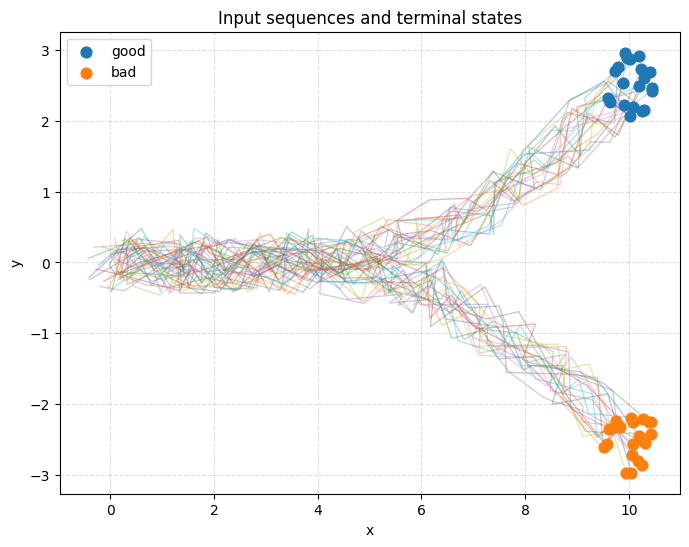

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    ax.plot(adata.X[idx, 0], adata.X[idx, 1], "-", lw=1, alpha=0.35)

mask_good = adata.obs["cluster"].to_numpy() == "good"
mask_bad = adata.obs["cluster"].to_numpy() == "bad"
ax.scatter(adata.X[mask_good, 0], adata.X[mask_good, 1], s=60, label="good", zorder=5)
ax.scatter(adata.X[mask_bad, 0], adata.X[mask_bad, 1], s=60, label="bad", zorder=5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Input sequences and terminal states")
ax.grid(ls="--", alpha=0.4)
ax.legend()
plt.show()


## Velocity vectors

The velocity is computed independently within each sequence by central differences, with one-sided differences at the endpoints.

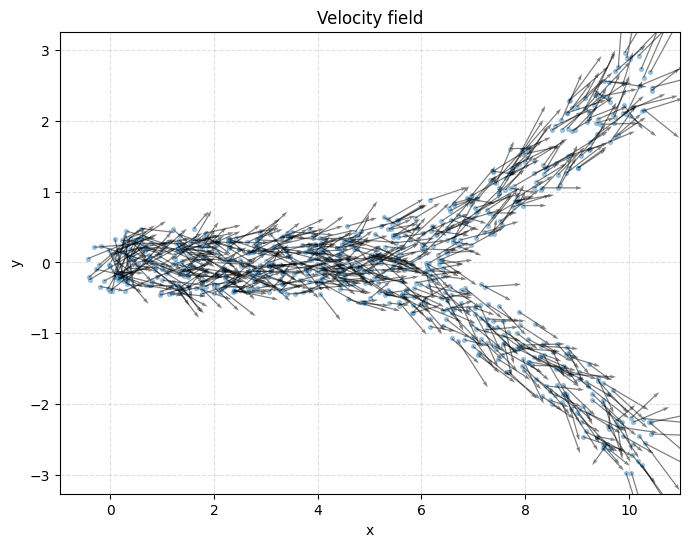

In [5]:
velocity = np.zeros_like(adata.X, dtype=float)

for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    points = np.asarray(adata.X[idx], dtype=float)

    if len(idx) == 1:
        velocity[idx] = 0.0
    elif len(idx) == 2:
        v = points[1] - points[0]
        velocity[idx[0]] = v
        velocity[idx[1]] = v
    else:
        velocity[idx[0]] = points[1] - points[0]
        velocity[idx[-1]] = points[-1] - points[-2]
        velocity[idx[1:-1]] = 0.5 * (points[2:] - points[:-2])

adata.obsm["velocity"] = velocity

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(adata.X[:, 0], adata.X[:, 1], s=8, alpha=0.35)
ax.quiver(
    adata.X[:, 0],
    adata.X[:, 1],
    velocity[:, 0],
    velocity[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.002,
    alpha=0.5,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Velocity field")
ax.grid(ls="--", alpha=0.4)
plt.show()


## Build and inspect the time-layered transition graph

With `transition_mode="time_layered"`, **cross-sequence costs are finite only between states with the same `time_idx`**. Same-sequence one-step forward dynamics has cost zero, while other inter-time jumps are infinite.

The inspection graph therefore implements the literal time restriction. The actual Good/Bad reach costs are computed by backward dynamic programming rather than by Dijkstra on this graph, so that at most one same-time member switch is allowed per forecast step.


In [6]:
graph = build_terminal_state_graph(
    adata,
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    sequence_edge_mode="adjacent",
    transition_mode="time_layered",
)

# Sanity checks for the literal time restriction.
seq_values = adata.obs["seq_id"].to_numpy(dtype=int)
time_values = adata.obs["time_idx"].to_numpy(dtype=int)
first_seq = int(np.unique(seq_values)[0])
other_seq = int(np.unique(seq_values)[-1])

idx0 = np.flatnonzero(seq_values == first_seq)
idx0 = idx0[np.argsort(time_values[idx0])]
idx1 = np.flatnonzero(seq_values == other_seq)
idx1 = idx1[np.argsort(time_values[idx1])]

print("natural advance t0 -> t1:", graph.weights[idx0[0], idx0[1]])
print("forbidden direct t0 -> t2:", graph.weights[idx0[0], idx0[2]])
print("same-time cross-member t0 -> t0:", graph.weights[idx0[0], idx1[0]])
print("forbidden cross-member t0 -> t1:", graph.weights[idx0[0], idx1[1]])
print("number of terminal states:", len(graph.terminal_indices))


natural advance t0 -> t1: 0.0
forbidden direct t0 -> t2: inf
same-time cross-member t0 -> t0: 0.12333686917171811
forbidden cross-member t0 -> t1: inf
number of terminal states: 40


## New $\varepsilon$ debut functions: time-layered minimax recursion

For $p=\infty$, the non-autonomous recursion is

$$
C_{A,\infty}(m,k)
=
\min_n
\max\left\{
 d\bigl(x_m^k,x_n^k\bigr),
 C_{A,\infty}(n,k+1)
\right\}.
$$

Thus a trajectory can switch member at the current time but cannot jump to a different time index.

In [7]:
eps_attracting_basin_shortest_path(
    adata,
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="adjacent",
    transition_mode="time_layered",
    output_key="eps_attracting_basin_sp",
    distance_key="eps_distance_sp",
    terminal_class_key="terminal_class",
    store_next_hop=True,
)

adata.obs[[
    "cluster",
    "time_idx",
    "terminal_class",
    "eps_attracting_basin_sp_good",
    "eps_attracting_basin_sp_bad",
    "eps_attracting_basin_sp_landscape",
]].head()

,cluster,time_idx,terminal_class,eps_attracting_basin_sp_good,eps_attracting_basin_sp_bad,eps_attracting_basin_sp_landscape
0,others,0,good,-0.043361,0.043361,-0.043361
1,others,1,good,-0.043361,0.043361,-0.043361
2,others,2,good,-0.043361,0.043361,-0.043361
3,others,3,good,-0.043361,0.043361,-0.043361
4,others,4,good,-0.043361,0.043361,-0.043361


## New $\varepsilon_\Sigma$ debut functions: time-layered additive recursion

For $p=1$, the cumulative-cost recursion is

$$
C_{A,1}(m,k)
=
\min_n
\left[
 d\bigl(x_m^k,x_n^k\bigr)
 + C_{A,1}(n,k+1)
\right].
$$

Only one same-time member switch is allowed at each forecast step.

In [8]:
eps_sum_attracting_basin_shortest_path(
    adata,
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="adjacent",
    transition_mode="time_layered",
    output_key="eps_sum_attracting_basin_sp",
    distance_key="eps_sum_distance_sp",
)

adata.obs[[
    "cluster",
    "time_idx",
    "eps_sum_attracting_basin_sp_good",
    "eps_sum_attracting_basin_sp_bad",
    "eps_sum_attracting_basin_sp_landscape",
]].head()

,cluster,time_idx,eps_sum_attracting_basin_sp_good,eps_sum_attracting_basin_sp_bad,eps_sum_attracting_basin_sp_landscape
0,others,0,-0.043361,0.043361,-0.043361
1,others,1,-0.043361,0.043361,-0.043361
2,others,2,-0.043361,0.043361,-0.043361
3,others,3,-0.043361,0.043361,-0.043361
4,others,4,-0.043361,0.043361,-0.043361


## Query an arbitrary state $x$: $C_{G,p}(x)$, $C_{B,p}(x)$, and realizing paths

After the ensemble debut functions have been learned, an external state $x$ is
queried by supplying the cost from $x$ to the ensemble states.  In the
**time-layered** model, only ensemble states at the same `time_idx` are
admissible entry states.

For each target outcome $A\in\{G,B\}$, the helper
`epsbasin.shortest_path.minimum_epsilon_and_paths_to_good_bad` returns both

$$
C_{A,p}(t_k,x)
$$

and one optimal path that realizes this value.  A path consists of

- a dashed **entry/switch** segment, which carries the perturbation cost; and
- a solid **natural-advance** segment, which follows the selected ensemble
  member to the next time layer at zero cost.

For $p=1$, the path value is the sum of the perturbation costs.  For
$p=\infty$, it is their maximum.

This notebook requires the replacement `epsbasin/shortest_path.py` supplied as `shortest_path_external_paths_v3.py`.


In [9]:
# A query chosen early enough that the L1 and L-infinity optimal paths
# can differ.  This state is not one of the ensemble observations.
QUERY_TIME_IDX = 8
x_query = np.array([4.2, 0.2], dtype=float)

# Cost from x to the ensemble.  For the time-layered query we make the
# same-time restriction explicit by setting all other time layers to infinity.
query_costs = np.full(adata.n_obs, np.inf, dtype=float)
same_time_mask = (
    adata.obs["time_idx"].to_numpy(dtype=int) == QUERY_TIME_IDX
)
X_same_time = np.asarray(adata.X[same_time_mask], dtype=float)
query_costs[same_time_mask] = np.linalg.norm(
    X_same_time - x_query[None, :],
    axis=1,
)

query_result_inf = minimum_epsilon_and_paths_to_good_bad(
    adata,
    x_query,
    query_costs,
    output_key="eps_attracting_basin_sp",
    time_value=QUERY_TIME_IDX,
)
query_result_one = minimum_epsilon_and_paths_to_good_bad(
    adata,
    x_query,
    query_costs,
    output_key="eps_sum_attracting_basin_sp",
    time_value=QUERY_TIME_IDX,
)

for name, result in [
    (r"$p=\infty$", query_result_inf),
    (r"$p=1$", query_result_one),
]:
    print(
        f"{name}: "
        f"C_G={result.epsilon_good:.4f}, "
        f"C_B={result.epsilon_bad:.4f}, "
        f"S=C_B-C_G={result.score_good:.4f}"
    )
    print(
        "  realized by paths: "
        f"Good={result.path_good.realized_value:.4f}, "
        f"Bad={result.path_bad.realized_value:.4f}"
    )
    assert np.isclose(
        result.path_good.realized_value,
        result.epsilon_good,
    )
    assert np.isclose(
        result.path_bad.realized_value,
        result.epsilon_bad,
    )


def optimal_path_table(path, adata_obj):
    """Human-readable table of the transitions in one reconstructed path."""
    rows = []
    for step_no, step in enumerate(path.steps):
        if step.source_index is None:
            source = "x"
            source_seq = "external"
            source_time = QUERY_TIME_IDX
        else:
            source = int(step.source_index)
            source_seq = adata_obj.obs.iloc[step.source_index]["seq_id"]
            source_time = adata_obj.obs.iloc[step.source_index]["time_idx"]

        destination = int(step.destination_index)
        rows.append(
            {
                "step": step_no,
                "kind": step.kind,
                "source": source,
                "source_seq": source_seq,
                "source_time": source_time,
                "destination": destination,
                "destination_seq": adata_obj.obs.iloc[destination]["seq_id"],
                "destination_time": adata_obj.obs.iloc[destination]["time_idx"],
                "cost": step.cost,
            }
        )
    return pd.DataFrame(rows)


print("\nL-infinity path to Good")
display(optimal_path_table(query_result_inf.path_good, adata))
print("L-infinity path to Bad")
display(optimal_path_table(query_result_inf.path_bad, adata))
print("L1 path to Good")
display(optimal_path_table(query_result_one.path_good, adata))
print("L1 path to Bad")
display(optimal_path_table(query_result_one.path_bad, adata))

$p=\infty$: C_G=0.0893, C_B=0.1155, S=C_B-C_G=0.0262
  realized by paths: Good=0.0893, Bad=0.1155
$p=1$: C_G=0.0893, C_B=0.1626, S=C_B-C_G=0.0733
  realized by paths: Good=0.0893, Bad=0.1626

L-infinity path to Good


,step,kind,source,source_seq,source_time,destination,destination_seq,destination_time,cost
0,0,entry,x,external,8,28,1,8,0.089276
1,1,advance,28,1,8,29,1,9,0.000000
2,2,advance,29,1,9,30,1,10,0.000000
3,3,advance,30,1,10,31,1,11,0.000000
4,4,advance,31,1,11,32,1,12,0.000000
5,5,advance,32,1,12,33,1,13,0.000000
6,6,advance,33,1,13,34,1,14,0.000000
7,7,advance,34,1,14,35,1,15,0.000000
8,8,advance,35,1,15,36,1,16,0.000000
9,9,advance,36,1,16,37,1,17,0.000000


L-infinity path to Bad


,step,kind,source,source_seq,source_time,destination,destination_seq,destination_time,cost
0,0,entry,x,external,8,128,6,8,0.115482
1,1,advance,128,6,8,129,6,9,0.000000
2,2,switch,129,6,9,469,23,9,0.062261
3,3,advance,469,23,9,470,23,10,0.000000
4,4,advance,470,23,10,471,23,11,0.000000
5,5,advance,471,23,11,472,23,12,0.000000
6,6,advance,472,23,12,473,23,13,0.000000
7,7,advance,473,23,13,474,23,14,0.000000
8,8,advance,474,23,14,475,23,15,0.000000
9,9,advance,475,23,15,476,23,16,0.000000


L1 path to Good


,step,kind,source,source_seq,source_time,destination,destination_seq,destination_time,cost
0,0,entry,x,external,8,28,1,8,0.089276
1,1,advance,28,1,8,29,1,9,0.000000
2,2,advance,29,1,9,30,1,10,0.000000
3,3,advance,30,1,10,31,1,11,0.000000
4,4,advance,31,1,11,32,1,12,0.000000
5,5,advance,32,1,12,33,1,13,0.000000
6,6,advance,33,1,13,34,1,14,0.000000
7,7,advance,34,1,14,35,1,15,0.000000
8,8,advance,35,1,15,36,1,16,0.000000
9,9,advance,36,1,16,37,1,17,0.000000


L1 path to Bad


,step,kind,source,source_seq,source_time,destination,destination_seq,destination_time,cost
0,0,entry,x,external,8,748,37,8,0.162571
1,1,advance,748,37,8,749,37,9,0.000000
2,2,advance,749,37,9,750,37,10,0.000000
3,3,advance,750,37,10,751,37,11,0.000000
4,4,advance,751,37,11,752,37,12,0.000000
5,5,advance,752,37,12,753,37,13,0.000000
6,6,advance,753,37,13,754,37,14,0.000000
7,7,advance,754,37,14,755,37,15,0.000000
8,8,advance,755,37,15,756,37,16,0.000000
9,9,advance,756,37,16,757,37,17,0.000000


### State-space visualization of the optimal Good/Bad paths

The gray curves are the training ensemble trajectories and the black star is
the external query $x$. Red and blue indicate paths toward Good and Bad,
respectively.

To make the intervention timing explicit, the two transition types are drawn
differently:

- **CONTROL (entry / same-time switch):** thick dashed, slightly curved arrow
  with a large arrowhead. The state immediately after control is marked by a
  diamond, and the perturbation magnitude is labeled as
  $\varepsilon=\mathrm{cost}$.
- **TIME EVOLUTION (natural advance):** thinner solid straight arrow. This is
  the zero-cost evolution of the selected ensemble member to the next time
  layer.

Thus every dashed arrow identifies exactly where a control perturbation is
inserted, whereas every solid arrow represents uncontrolled temporal
evolution.

In [33]:
query_result_inf

ExternalStatePathResult(epsilon_good=0.0892761702256436, epsilon_bad=0.11548166231965899, entry_index_good=28, entry_index_bad=128, path_cost='max', good_cluster_key='good', bad_cluster_key='bad', path_good=OptimalPath(target_label='good', path_cost='max', value=0.0892761702256436, steps=(PathStep(kind='entry', source_index=None, destination_index=28, cost=0.0892761702256436), PathStep(kind='advance', source_index=28, destination_index=29, cost=0.0), PathStep(kind='advance', source_index=29, destination_index=30, cost=0.0), PathStep(kind='advance', source_index=30, destination_index=31, cost=0.0), PathStep(kind='advance', source_index=31, destination_index=32, cost=0.0), PathStep(kind='advance', source_index=32, destination_index=33, cost=0.0), PathStep(kind='advance', source_index=33, destination_index=34, cost=0.0), PathStep(kind='advance', source_index=34, destination_index=35, cost=0.0), PathStep(kind='advance', source_index=35, destination_index=36, cost=0.0), PathStep(kind='advan

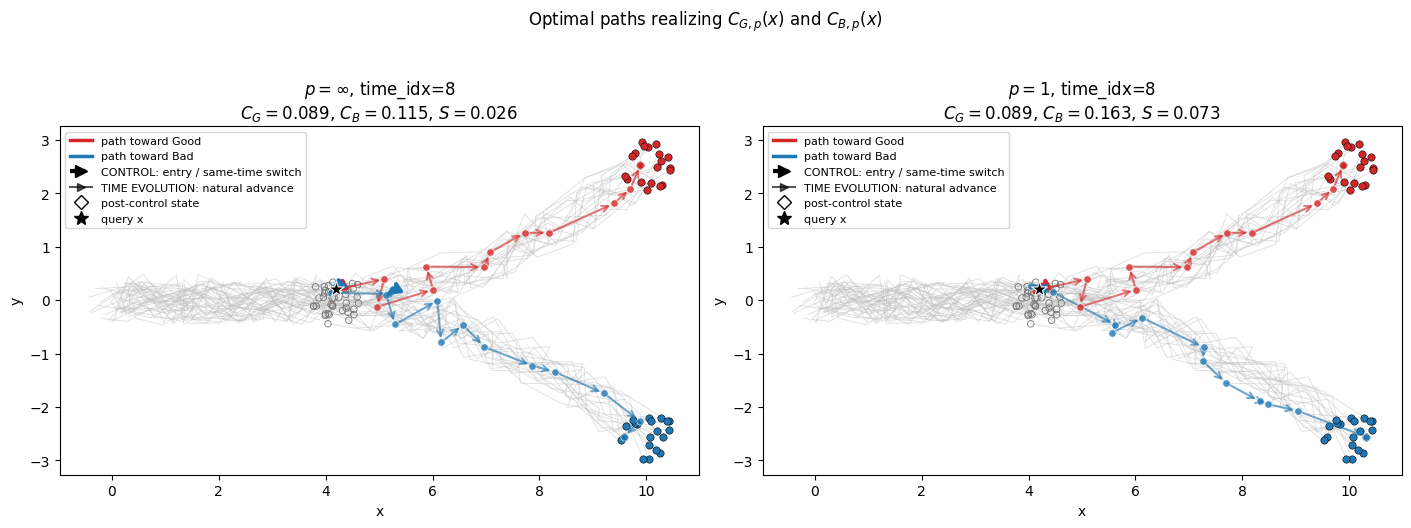

In [11]:
from matplotlib.lines import Line2D


def plot_query_paths(ax, result, *, title):
    X_all = np.asarray(adata.X, dtype=float)
    seq_values = adata.obs["seq_id"].to_numpy(dtype=int)
    time_values = adata.obs["time_idx"].to_numpy(dtype=int)

    # Background ensemble trajectories.
    for seq_id in np.unique(seq_values):
        idx = np.flatnonzero(seq_values == seq_id)
        idx = idx[np.argsort(time_values[idx])]
        ax.plot(
            X_all[idx, 0],
            X_all[idx, 1],
            color="0.75",
            linewidth=0.7,
            alpha=0.45,
            zorder=1,
        )

    # Ensemble states available at the query time.
    same_time_indices = np.flatnonzero(time_values == QUERY_TIME_IDX)
    ax.scatter(
        X_all[same_time_indices, 0],
        X_all[same_time_indices, 1],
        s=22,
        facecolors="none",
        edgecolors="0.45",
        linewidths=0.6,
        zorder=2,
    )

    # Terminal outcomes.
    terminal_good = np.flatnonzero(
        adata.obs["cluster"].astype(str).to_numpy() == "good"
    )
    terminal_bad = np.flatnonzero(
        adata.obs["cluster"].astype(str).to_numpy() == "bad"
    )
    ax.scatter(
        X_all[terminal_good, 0],
        X_all[terminal_good, 1],
        s=28,
        color="tab:red",
        marker="o",
        edgecolor="black",
        linewidth=0.4,
        zorder=3,
    )
    ax.scatter(
        X_all[terminal_bad, 0],
        X_all[terminal_bad, 1],
        s=28,
        color="tab:blue",
        marker="o",
        edgecolor="black",
        linewidth=0.4,
        zorder=3,
    )

    # External query state.
    ax.scatter(
        [x_query[0]],
        [x_query[1]],
        s=140,
        marker="*",
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=10,
    )

    def draw_optimal_path(path, color):
        """
        Draw one optimal path with two visually distinct transition types.

        CONTROL (entry / same-time switch)
          - thick dashed arrow
          - large filled arrow head
          - slight curvature
          - diamond at the post-control state
          - epsilon/cost label

        TIME EVOLUTION (natural advance)
          - thinner solid straight arrow
          - ordinary arrow head
          - no perturbation-cost label
        """
        visited = []
        control_destinations = []

        for step in path.steps:
            if step.source_index is None:
                p0 = x_query
            else:
                p0 = X_all[int(step.source_index)]
            p1 = X_all[int(step.destination_index)]

            is_control = step.kind in {"entry", "switch", "graph"}

            if is_control:
                # Perturbative control: same-time jump / entry.
                arrowprops = dict(
                    arrowstyle="-|>",
                    color=color,
                    linewidth=3.0,
                    linestyle="--",
                    mutation_scale=17,
                    shrinkA=4,
                    shrinkB=5,
                    alpha=1.0,
                    connectionstyle="arc3,rad=0.10",
                )
                zorder = 9
            else:
                # Natural time evolution: same member advances to next time.
                arrowprops = dict(
                    arrowstyle="->",
                    color=color,
                    linewidth=1.5,
                    linestyle="-",
                    mutation_scale=11,
                    shrinkA=3,
                    shrinkB=3,
                    alpha=0.60,
                    connectionstyle="arc3,rad=0.0",
                )
                zorder = 6

            ax.annotate(
                "",
                xy=(p1[0], p1[1]),
                xytext=(p0[0], p0[1]),
                arrowprops=arrowprops,
                zorder=zorder,
            )

            # if is_control:
            #     control_destinations.append(int(step.destination_index))

            #     # Explicitly label where the perturbation/control is applied.
            #     midpoint = 0.5 * (p0 + p1)
            #     if step.cost > 1e-10:
            #         label = rf"control $\varepsilon={step.cost:.2f}$"
            #     else:
            #         label = "control"

            #     ax.text(
            #         midpoint[0],
            #         midpoint[1],
            #         label,
            #         color=color,
            #         fontsize=7.5,
            #         fontweight="bold",
            #         ha="center",
            #         va="bottom",
            #         bbox=dict(
            #             boxstyle="round,pad=0.18",
            #             facecolor="white",
            #             edgecolor=color,
            #             linewidth=0.7,
            #             alpha=0.85,
            #         ),
            #         zorder=12,
            #     )

            visited.append(int(step.destination_index))

        # States used by the optimal path.
        if visited:
            unique_visited = np.unique(visited)
            ax.scatter(
                X_all[unique_visited, 0],
                X_all[unique_visited, 1],
                s=28,
                facecolor=color,
                edgecolor="white",
                linewidth=0.5,
                alpha=0.80,
                zorder=8,
            )

        # Diamond markers make control locations immediately visible.
        if control_destinations:
            control_destinations = np.unique(control_destinations)
            ax.scatter(
                X_all[control_destinations, 0],
                X_all[control_destinations, 1],
                s=70,
                marker="D",
                facecolor=color,
                edgecolor="black",
                linewidth=0.8,
                zorder=11,
            )

    draw_optimal_path(result.path_good, "tab:red")
    draw_optimal_path(result.path_bad, "tab:blue")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_title(
        title
        + "\n"
        + rf"$C_G={result.epsilon_good:.3f}$, "
          rf"$C_B={result.epsilon_bad:.3f}$, "
          rf"$S={result.score_good:.3f}$"
    )

    legend_handles = [
        Line2D(
            [0], [0], color="tab:red", lw=2.5,
            label="path toward Good",
        ),
        Line2D(
            [0], [0], color="tab:blue", lw=2.5,
            label="path toward Bad",
        ),
        Line2D(
            [0], [0], color="black", lw=3.0, ls="--",
            marker=">", markevery=[1], markersize=8,
            label="CONTROL: entry / same-time switch",
        ),
        Line2D(
            [0], [0], color="black", lw=1.5, ls="-", alpha=0.65,
            marker=">", markevery=[1], markersize=6,
            label="TIME EVOLUTION: natural advance",
        ),
        Line2D(
            [0], [0], marker="D", color="black", lw=0,
            markerfacecolor="white", markersize=7,
            label="post-control state",
        ),
        Line2D(
            [0], [0], marker="*", color="black", lw=0,
            markersize=10, label="query x",
        ),
    ]
    ax.legend(
        handles=legend_handles,
        frameon=True,
        fontsize=8,
        loc="upper left",
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.6),
    constrained_layout=True,
)
plot_query_paths(
    axes[0],
    query_result_inf,
    title=rf"$p=\infty$, time_idx={QUERY_TIME_IDX}",
)
plot_query_paths(
    axes[1],
    query_result_one,
    title=rf"$p=1$, time_idx={QUERY_TIME_IDX}",
)
fig.suptitle(
    r"Optimal paths realizing $C_{G,p}(x)$ and $C_{B,p}(x)$",
    y=1.02,
)
plt.show()

## Debut functions for $\varepsilon$

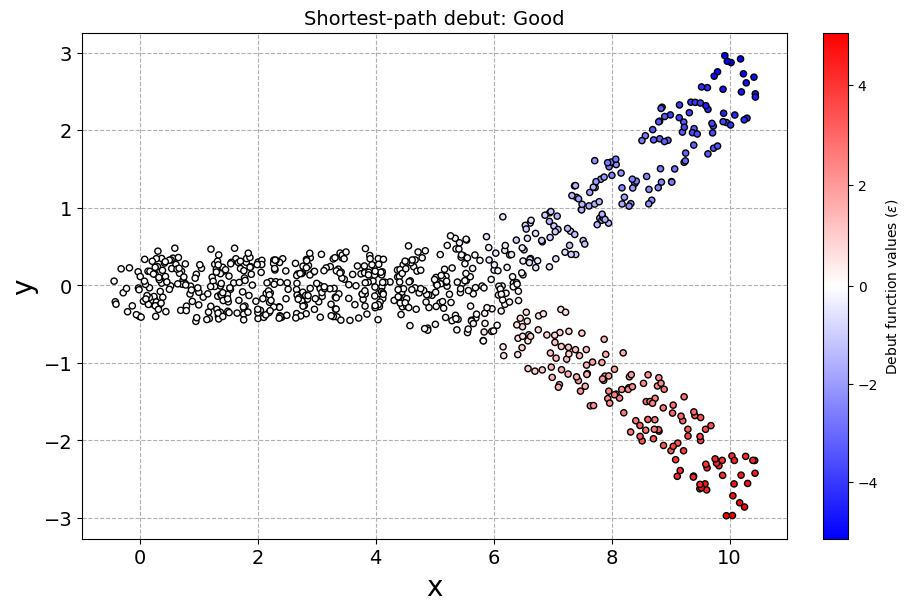

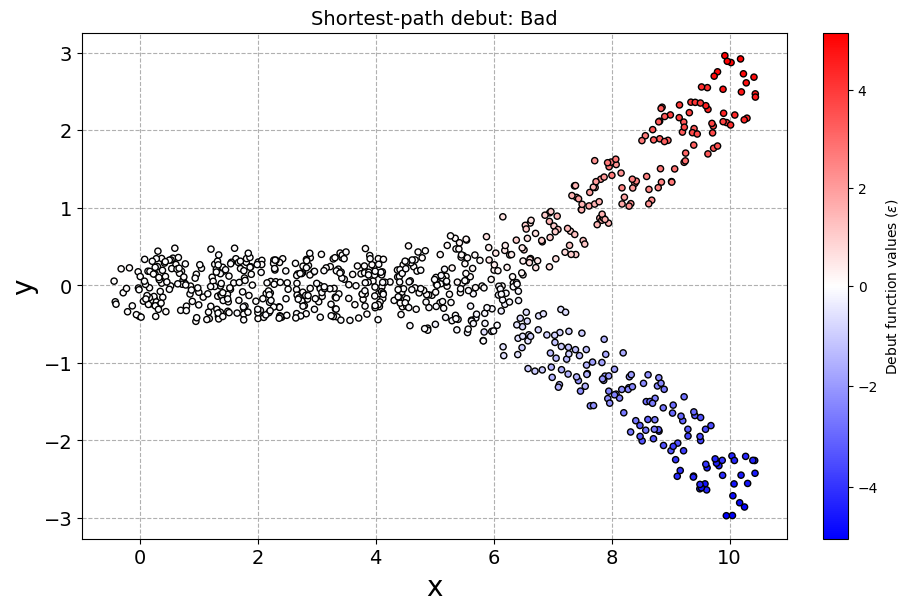

In [12]:
epsbasin.plot_debut(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_key="good",
    title="Shortest-path debut: Good",
)

epsbasin.plot_debut(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_key="bad",
    title="Shortest-path debut: Bad",
)


## Debut functions for $\varepsilon_\Sigma$

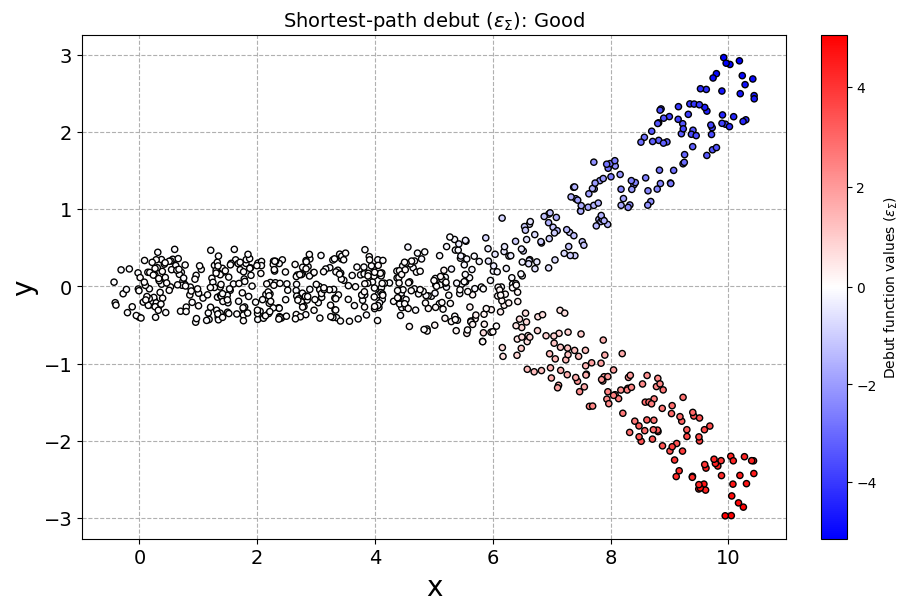

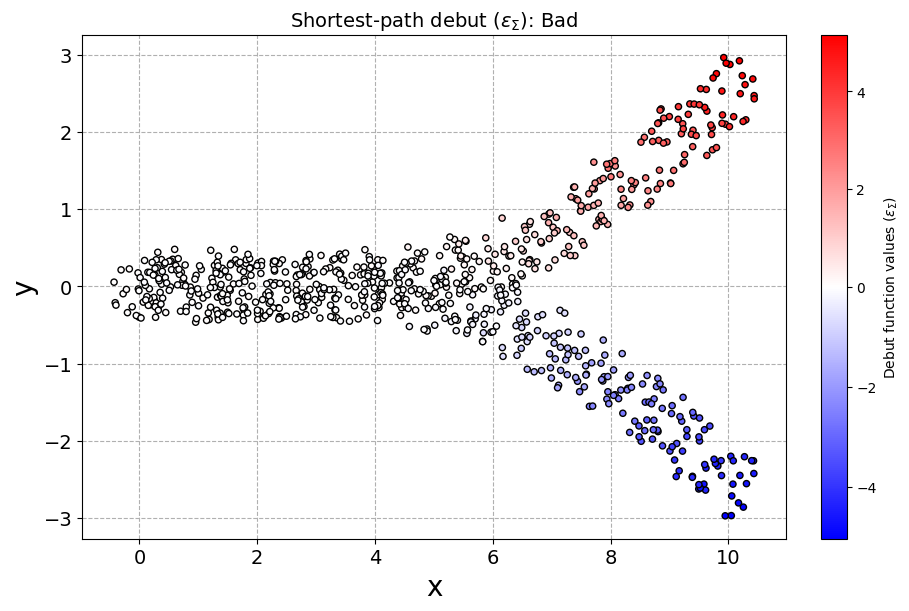

In [13]:
epsbasin.plot_debut(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_key="good",
    title=r"Shortest-path debut ($\varepsilon_\Sigma$): Good",
)

epsbasin.plot_debut(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_key="bad",
    title=r"Shortest-path debut ($\varepsilon_\Sigma$): Bad",
)


## Landscape

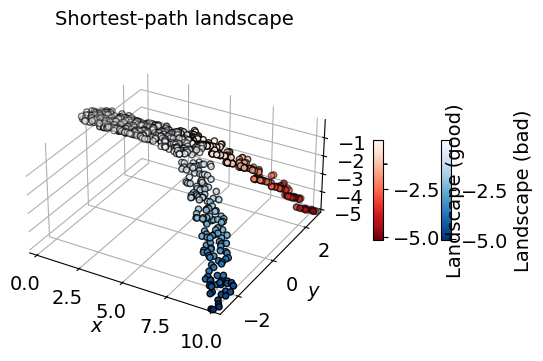

In [14]:
epsbasin.plot_landscape(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_keys=["good", "bad"],
    figsize=(10, 10),
    show_title=True,
    title="Shortest-path landscape",
)


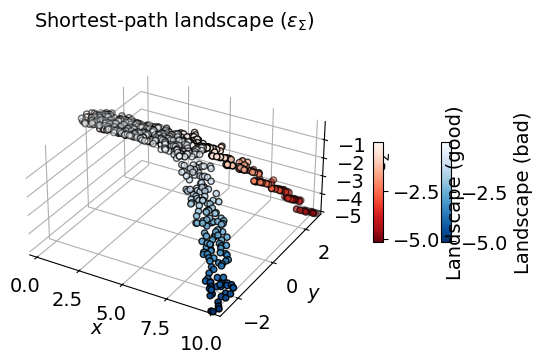

In [15]:
epsbasin.plot_landscape(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_keys=["good", "bad"],
    figsize=(10, 10),
    show_title=True,
    title=r"Shortest-path landscape ($\varepsilon_\Sigma$)",
)


## Attracting-basin visualization at a selected threshold

The old plotting function can be reused because the new implementation writes Good/Bad debut functions using the same `<eps_key>_good` / `<eps_key>_bad` naming convention.

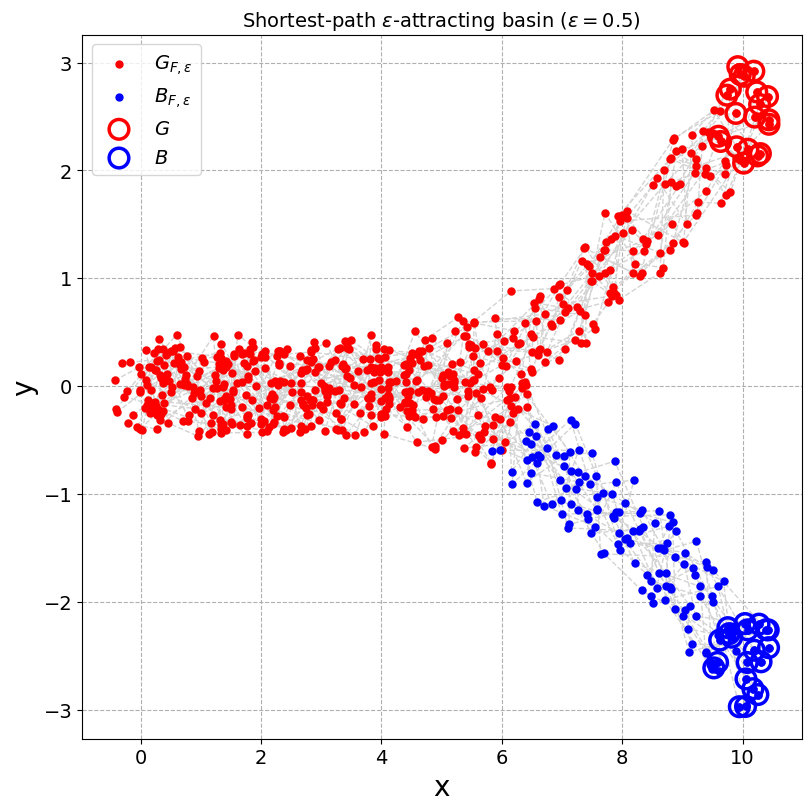

In [16]:
eps_threshold = 0.5

epsbasin.plot_attracting_basin(
    adata,
    eps_key="eps_attracting_basin_sp",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    eps_threshold=eps_threshold,
    figsize=(8, 8),
    title=rf"Shortest-path $\varepsilon$-attracting basin ($\varepsilon={eps_threshold}$)",
)


## Basic consistency checks

In [17]:
# Each observation inherits the natural terminal class of its own sequence.
for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    natural_terminal = adata.obs["cluster"].iloc[idx[-1]]
    assert np.all(adata.obs["terminal_class"].iloc[idx].to_numpy() == natural_terminal)

# The two signed debut functions are complementary under the Good/Bad terminal partition.
np.testing.assert_allclose(
    adata.obs["eps_attracting_basin_sp_good"].to_numpy(),
    -adata.obs["eps_attracting_basin_sp_bad"].to_numpy(),
)
np.testing.assert_allclose(
    adata.obs["eps_sum_attracting_basin_sp_good"].to_numpy(),
    -adata.obs["eps_sum_attracting_basin_sp_bad"].to_numpy(),
)

print("All consistency checks passed.")


All consistency checks passed.


## Leave-one-sequence-out cross-validation

For each `seq_id`, the complete trajectory is removed before constructing the landscape. For a held-out state $x$ at time $t_k$, **only training states at the same `time_idx` are eligible entry states**.

For a non-terminal time,

$$
C_{A,\infty}(t_k,x)
=
\min_n
\max\left\{
 d\bigl(x,x_n(t_k)\bigr),
 C_{A,\infty}\bigl(n,t_{k+1}\bigr)
\right\},
$$

and

$$
C_{A,1}(t_k,x)
=
\min_n
\left[
 d\bigl(x,x_n(t_k)\bigr)
 + C_{A,1}\bigl(n,t_{k+1}\bigr)
\right].
$$

The terminal label of the held-out trajectory is used only for scoring the prediction, never for training.

In [18]:
def evaluate_external_state(
    adata_train,
    x,
    costs,
    *,
    output_key,
    time_value,
):
    """Evaluate a held-out/background state using the time-layered package helper."""
    return minimum_epsilon_to_good_bad(
        adata_train,
        x,
        costs,
        output_key=output_key,
        time_value=time_value,
    )

In [19]:
def leave_one_sequence_out_cv(
    adata_full,
    *,
    path_cost="max",
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    tie_tol=1e-12,
    verbose=True,
):
    """LOSO-CV with strict same-time entry and time-layered dynamics."""
    if path_cost not in {"max", "sum"}:
        raise ValueError("path_cost must be 'max' or 'sum'.")

    seq_values = adata_full.obs[seq_key].to_numpy()
    time_values = adata_full.obs[time_key].to_numpy()
    all_indices = np.arange(adata_full.n_obs)
    seq_ids_unique = list(pd.unique(seq_values))

    if cost_matrix_key in adata_full.uns:
        full_cost = np.asarray(adata_full.uns[cost_matrix_key], dtype=float)
    else:
        from sklearn.metrics import pairwise_distances
        full_cost = pairwise_distances(adata_full.X)

    if full_cost.shape != (adata_full.n_obs, adata_full.n_obs):
        raise ValueError("The full cost matrix has an incompatible shape.")

    rows = []

    for fold, heldout_seq in enumerate(seq_ids_unique, start=1):
        test_indices = all_indices[seq_values == heldout_seq]
        test_indices = test_indices[np.argsort(time_values[test_indices])]
        train_indices = all_indices[seq_values != heldout_seq]

        adata_train = adata_full[train_indices].copy()
        adata_train.uns[cost_matrix_key] = full_cost[
            np.ix_(train_indices, train_indices)
        ].copy()

        if path_cost == "max":
            output_key = "cv_eps_attracting_basin_sp"
            eps_attracting_basin_shortest_path(
                adata_train,
                seq_key=seq_key,
                time_key=time_key,
                cluster_key=cluster_key,
                good_cluster_key=good_cluster_key,
                bad_cluster_key=bad_cluster_key,
                cost_matrix_key=cost_matrix_key,
                sequence_edge_mode="adjacent",
                transition_mode="time_layered",
                output_key=output_key,
            )
        else:
            output_key = "cv_eps_sum_attracting_basin_sp"
            eps_sum_attracting_basin_shortest_path(
                adata_train,
                seq_key=seq_key,
                time_key=time_key,
                cluster_key=cluster_key,
                good_cluster_key=good_cluster_key,
                bad_cluster_key=bad_cluster_key,
                cost_matrix_key=cost_matrix_key,
                sequence_edge_mode="adjacent",
                transition_mode="time_layered",
                output_key=output_key,
            )

        true_label = str(adata_full.obs.iloc[test_indices[-1]][cluster_key])
        if true_label not in {good_cluster_key, bad_cluster_key}:
            raise ValueError(
                f"Held-out sequence {heldout_seq!r} does not terminate in "
                f"{good_cluster_key!r} or {bad_cluster_key!r}."
            )

        train_time_values = adata_train.obs[time_key].to_numpy()

        for step, global_index in enumerate(test_indices):
            time_value = time_values[global_index]
            x_query = np.asarray(
                adata_full.X[global_index],
                dtype=float,
            ).reshape(-1)

            # Same-time entry only. The package helper also enforces this, but
            # setting the other entries to inf makes the rule explicit here.
            costs_x_to_train = np.asarray(
                full_cost[global_index, train_indices],
                dtype=float,
            ).copy()
            costs_x_to_train[train_time_values != time_value] = np.inf

            result = evaluate_external_state(
                adata_train,
                x_query,
                costs_x_to_train,
                output_key=output_key,
                time_value=time_value,
            )

            score_good = result.epsilon_bad - result.epsilon_good
            if score_good > tie_tol:
                prediction = good_cluster_key
            elif score_good < -tie_tol:
                prediction = bad_cluster_key
            else:
                prediction = "tie"

            entry_good_local = result.entry_index_good
            entry_bad_local = result.entry_index_bad
            entry_good_global = (
                -1
                if entry_good_local < 0
                else int(train_indices[entry_good_local])
            )
            entry_bad_global = (
                -1
                if entry_bad_local < 0
                else int(train_indices[entry_bad_local])
            )

            rows.append(
                {
                    "path_cost": path_cost,
                    "seq_id": heldout_seq,
                    "step": step,
                    "time_idx": time_value,
                    "fraction": (
                        0.0
                        if len(test_indices) == 1
                        else step / (len(test_indices) - 1)
                    ),
                    "global_index": int(global_index),
                    "x": float(adata_full.X[global_index, 0]),
                    "y": float(adata_full.X[global_index, 1]),
                    "true_label": true_label,
                    "epsilon_good": result.epsilon_good,
                    "epsilon_bad": result.epsilon_bad,
                    "margin_good": score_good,
                    "prediction": prediction,
                    "correct": prediction == true_label,
                    "entry_good_global_index": entry_good_global,
                    "entry_bad_global_index": entry_bad_global,
                }
            )

        if verbose:
            print(
                f"[{fold:02d}/{len(seq_ids_unique):02d}] "
                f"held out seq_id={heldout_seq!r}"
            )

    return pd.DataFrame(rows)

### Run LOSO-CV for ordinary $\varepsilon$

Each training landscape is recomputed with `transition_mode="time_layered"`. The held-out query can enter only the training states at its own `time_idx`.

In [20]:
cv_eps = leave_one_sequence_out_cv(
    adata,
    path_cost="max",
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    verbose=True,
)

cv_eps.head(10)

[01/40] held out seq_id=np.int64(0)
[02/40] held out seq_id=np.int64(1)
[03/40] held out seq_id=np.int64(2)
[04/40] held out seq_id=np.int64(3)
[05/40] held out seq_id=np.int64(4)
[06/40] held out seq_id=np.int64(5)
[07/40] held out seq_id=np.int64(6)
[08/40] held out seq_id=np.int64(7)
[09/40] held out seq_id=np.int64(8)
[10/40] held out seq_id=np.int64(9)
[11/40] held out seq_id=np.int64(10)
[12/40] held out seq_id=np.int64(11)
[13/40] held out seq_id=np.int64(12)
[14/40] held out seq_id=np.int64(13)
[15/40] held out seq_id=np.int64(14)
[16/40] held out seq_id=np.int64(15)
[17/40] held out seq_id=np.int64(16)
[18/40] held out seq_id=np.int64(17)
[19/40] held out seq_id=np.int64(18)
[20/40] held out seq_id=np.int64(19)
[21/40] held out seq_id=np.int64(20)
[22/40] held out seq_id=np.int64(21)
[23/40] held out seq_id=np.int64(22)
[24/40] held out seq_id=np.int64(23)
[25/40] held out seq_id=np.int64(24)
[26/40] held out seq_id=np.int64(25)
[27/40] held out seq_id=np.int64(26)
[28/40] hel

,path_cost,seq_id,step,time_idx,fraction,global_index,x,y,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct,entry_good_global_index,entry_bad_global_index
0,max,0,0,0,0.000000,0,0.392749,0.070632,good,0.045768,0.048356,0.002588,good,True,160,160
1,max,0,1,1,0.052632,1,0.710780,0.182812,good,0.043444,0.043444,0.000000,tie,False,101,101
2,max,0,2,2,0.105263,2,1.004222,-0.088817,good,0.059007,0.059007,0.000000,tie,False,782,782
3,max,0,3,3,0.157895,3,1.540252,-0.050838,good,0.021054,0.047629,0.026575,good,True,263,263
4,max,0,4,4,0.210526,4,1.767755,-0.296941,good,0.035485,0.051179,0.015694,good,True,164,164
5,max,0,5,5,0.263158,5,2.275895,0.325172,good,0.035352,0.043361,0.008009,good,True,385,505
6,max,0,6,6,0.315789,6,3.547269,0.008826,good,0.146134,0.146134,0.000000,tie,False,546,546
7,max,0,7,7,0.368421,7,4.108171,-0.017590,good,0.104761,0.104761,0.000000,tie,False,27,27
8,max,0,8,8,0.421053,8,4.065269,-0.273527,good,0.030749,0.073283,0.042534,good,True,108,588
9,max,0,9,9,0.473684,9,4.453780,-0.275514,good,0.121955,0.070527,-0.051428,bad,False,209,509


### Terminal-state prediction accuracy

The last state of each held-out trajectory is one independent terminal
prediction.  `accuracy_all` counts ties as incorrect; `accuracy_resolved`
reports accuracy only among non-tied predictions.

In [21]:
terminal_cv = (
    cv_eps.sort_values(["seq_id", "step"])
    .groupby("seq_id", sort=False)
    .tail(1)
    .reset_index(drop=True)
)

accuracy_all = terminal_cv["correct"].mean()
resolved = terminal_cv["prediction"] != "tie"
accuracy_resolved = (
    terminal_cv.loc[resolved, "correct"].mean() if resolved.any() else np.nan
)
tie_rate = (~resolved).mean()

print(f"terminal accuracy (ties incorrect): {accuracy_all:.3f}")
print(f"terminal accuracy (resolved only):  {accuracy_resolved:.3f}")
print(f"terminal tie rate:                  {tie_rate:.3f}")

display(terminal_cv[[
    "seq_id",
    "true_label",
    "epsilon_good",
    "epsilon_bad",
    "margin_good",
    "prediction",
    "correct",
]])

terminal accuracy (ties incorrect): 1.000
terminal accuracy (resolved only):  1.000
terminal tie rate:                  0.000


,seq_id,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct
0,0,good,0.079574,4.958530,4.878957,good,True
1,1,good,0.225839,4.729932,4.504093,good,True
2,2,good,0.150477,4.891290,4.740812,good,True
3,3,good,0.126064,4.815690,4.689626,good,True
4,4,good,0.060187,4.486144,4.425957,good,True
5,5,good,0.041265,4.676571,4.635306,good,True
6,6,good,0.041265,4.635432,4.594168,good,True
7,7,good,0.051427,4.360574,4.309148,good,True
8,8,good,0.066509,5.071723,5.005214,good,True
9,9,good,0.079574,4.905758,4.826184,good,True


### Time-dependent score surfaces $S_p(t,x)=C_{B,p}(t,x)-C_{G,p}(t,x)$

Because the system is treated as non-autonomous, the landscape is now **time dependent**. Choose a forecast layer with `SURFACE_TIME_IDX` below. Only ensemble states at that same time are admissible switching targets.

For a non-terminal layer,

$$
S_p(t_k,x)=C_{B,p}(t_k,x)-C_{G,p}(t_k,x),
$$

with $S_p>0$ favoring Good. The default is the second-to-last time layer, where the two outcomes are already well separated but the terminal outcome has not yet been reached.

max: time-layered recurrence max error = 0.000e+00
sum: time-layered recurrence max error = 0.000e+00
eps_attracting_basin_sp: 12 background-query checks passed at time 18.
eps_sum_attracting_basin_sp: 12 background-query checks passed at time 18.
surface time_idx = 18
S_inf range = [-4.2499, 4.2305]
S_1 range   = [-4.3315, 4.2372]


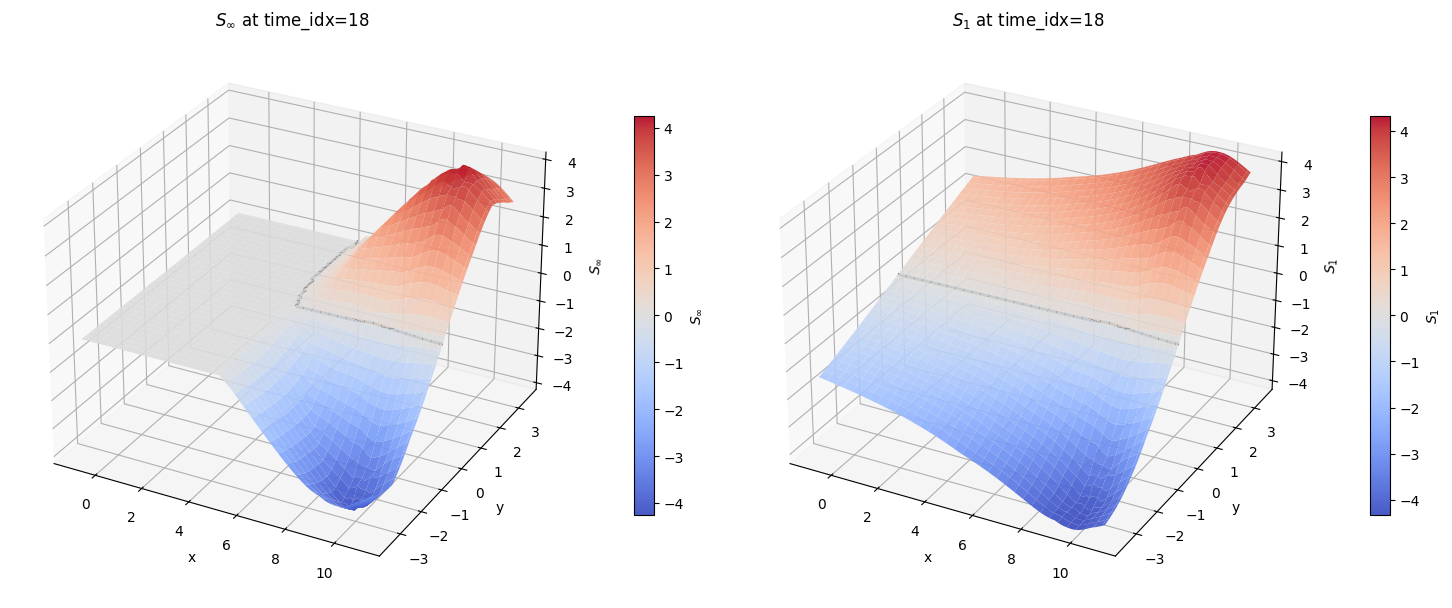

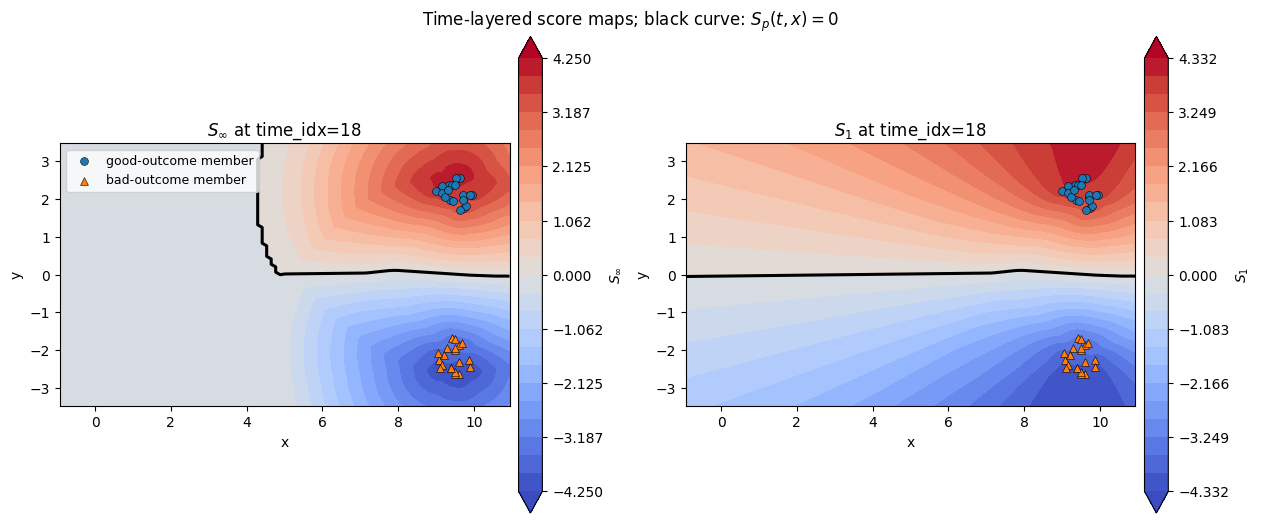

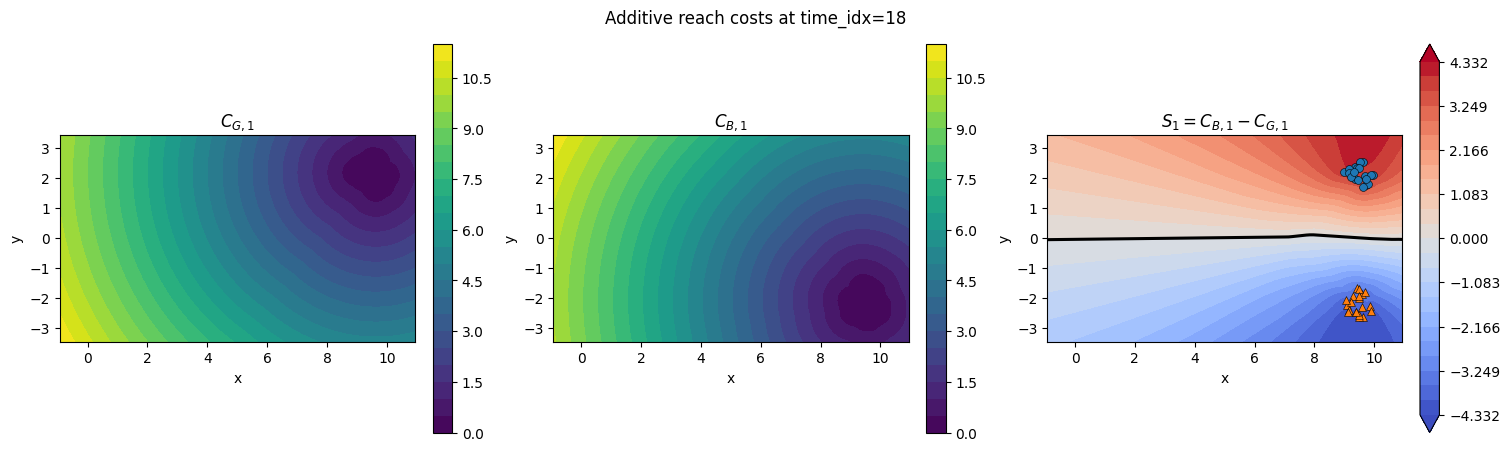

In [22]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

SURFACE_TIME_IDX = int(adata.obs["time_idx"].max()) - 1
SURFACE_NX = 101
SURFACE_NY = 101
SAVE_SCORE_SURFACE_FIGURES = False
SCORE_SURFACE_OUTPUT_DIR = Path("figures")
if SAVE_SCORE_SURFACE_FIGURES:
    SCORE_SURFACE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _finite_symmetric_limit(values):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return 1.0
    value = float(np.max(np.abs(finite)))
    return 1.0 if value == 0.0 else value


def _time_layer_indices(adata_obj, time_value):
    seq_values = adata_obj.obs["seq_id"].to_numpy()
    time_values = adata_obj.obs["time_idx"].to_numpy()
    seq_ids_here = list(pd.unique(seq_values))
    unique_times = np.sort(pd.unique(time_values))

    matches = np.flatnonzero(unique_times == time_value)
    if matches.size != 1:
        raise ValueError(f"time_idx={time_value!r} is not in the data.")
    t_pos = int(matches[0])

    current = []
    following = []
    for sid in seq_ids_here:
        idx = np.flatnonzero(seq_values == sid)
        idx = idx[np.argsort(time_values[idx])]
        current_match = idx[time_values[idx] == time_value]
        if current_match.size != 1:
            raise ValueError(
                f"seq_id={sid!r} has {current_match.size} states at time {time_value}."
            )
        current.append(int(current_match[0]))
        if t_pos < unique_times.size - 1:
            next_time = unique_times[t_pos + 1]
            next_match = idx[time_values[idx] == next_time]
            if next_match.size != 1:
                raise ValueError(
                    f"seq_id={sid!r} has {next_match.size} states at time {next_time}."
                )
            following.append(int(next_match[0]))

    return (
        np.asarray(current, dtype=int),
        None if not following else np.asarray(following, dtype=int),
        unique_times,
    )


def compute_time_layered_score_surface(
    adata_obj,
    *,
    time_value,
    distance_good_key,
    distance_bad_key,
    path_cost,
    score_label,
    nx=SURFACE_NX,
    ny=SURFACE_NY,
    pad_x=0.5,
    pad_y=0.5,
):
    """Evaluate S_p(t,x) using only the selected time layer."""
    if path_cost not in {"max", "sum"}:
        raise ValueError("path_cost must be 'max' or 'sum'.")

    X = np.asarray(adata_obj.X, dtype=float)
    current, following, unique_times = _time_layer_indices(
        adata_obj,
        time_value,
    )
    X_current = X[current]

    x_grid = np.linspace(X[:, 0].min() - pad_x, X[:, 0].max() + pad_x, nx)
    y_grid = np.linspace(X[:, 1].min() - pad_y, X[:, 1].max() + pad_y, ny)
    XX, YY = np.meshgrid(x_grid, y_grid)
    points = np.column_stack([XX.ravel(), YY.ravel()])
    entry = np.linalg.norm(
        points[:, None, :] - X_current[None, :, :],
        axis=2,
    )

    if following is None:
        labels = adata_obj.obs.iloc[current]["cluster"].astype(str).to_numpy()
        good_cols = np.flatnonzero(labels == "good")
        bad_cols = np.flatnonzero(labels == "bad")
        cost_good = np.min(entry[:, good_cols], axis=1)
        cost_bad = np.min(entry[:, bad_cols], axis=1)
    else:
        future_good = adata_obj.obs.iloc[following][
            distance_good_key
        ].to_numpy(dtype=float)
        future_bad = adata_obj.obs.iloc[following][
            distance_bad_key
        ].to_numpy(dtype=float)

        if path_cost == "max":
            cost_good = np.min(
                np.maximum(entry, future_good[None, :]),
                axis=1,
            )
            cost_bad = np.min(
                np.maximum(entry, future_bad[None, :]),
                axis=1,
            )
        else:
            cost_good = np.min(entry + future_good[None, :], axis=1)
            cost_bad = np.min(entry + future_bad[None, :], axis=1)

    score = cost_bad - cost_good
    return {
        "label": score_label,
        "time_value": time_value,
        "X": XX,
        "Y": YY,
        "score": score.reshape(YY.shape),
        "cost_good": cost_good.reshape(YY.shape),
        "cost_bad": cost_bad.reshape(YY.shape),
        "current_indices": current,
        "xlim": (x_grid[0], x_grid[-1]),
        "ylim": (y_grid[0], y_grid[-1]),
    }


def validate_time_layered_recurrence(
    adata_obj,
    *,
    distance_good_key,
    distance_bad_key,
    path_cost,
    atol=1e-10,
):
    """Check every time layer against the time-layered Bellman recursion."""
    X = np.asarray(adata_obj.X, dtype=float)
    full_cost = np.asarray(adata_obj.uns["cost_matrix"], dtype=float)
    times = np.sort(pd.unique(adata_obj.obs["time_idx"]))
    d_good = adata_obj.obs[distance_good_key].to_numpy(dtype=float)
    d_bad = adata_obj.obs[distance_bad_key].to_numpy(dtype=float)

    max_error = 0.0
    for t_pos, time_value in enumerate(times):
        current, following, _ = _time_layer_indices(adata_obj, time_value)
        switch = full_cost[np.ix_(current, current)]

        if following is None:
            labels = adata_obj.obs.iloc[current]["cluster"].astype(str).to_numpy()
            good_targets = current[labels == "good"]
            bad_targets = current[labels == "bad"]
            expected_good = np.min(
                full_cost[np.ix_(current, good_targets)],
                axis=1,
            )
            expected_bad = np.min(
                full_cost[np.ix_(current, bad_targets)],
                axis=1,
            )
        else:
            if path_cost == "max":
                expected_good = np.min(
                    np.maximum(switch, d_good[following][None, :]),
                    axis=1,
                )
                expected_bad = np.min(
                    np.maximum(switch, d_bad[following][None, :]),
                    axis=1,
                )
            else:
                expected_good = np.min(
                    switch + d_good[following][None, :],
                    axis=1,
                )
                expected_bad = np.min(
                    switch + d_bad[following][None, :],
                    axis=1,
                )

        max_error = max(
            max_error,
            float(np.max(np.abs(expected_good - d_good[current]))),
            float(np.max(np.abs(expected_bad - d_bad[current]))),
        )

    print(f"{path_cost}: time-layered recurrence max error = {max_error:.3e}")
    if max_error > atol:
        raise AssertionError(
            f"{path_cost} distances do not satisfy the time-layered recurrence."
        )


def validate_background_queries(
    adata_obj,
    *,
    time_value,
    output_key,
    surface,
    n_checks=12,
    random_state=0,
    atol=1e-10,
):
    """Compare direct surface evaluation with the package external-state helper."""
    rng = np.random.default_rng(random_state)
    current = surface["current_indices"]
    X_current = np.asarray(adata_obj.X[current], dtype=float)

    xmin, xmax = surface["xlim"]
    ymin, ymax = surface["ylim"]
    points = np.column_stack([
        rng.uniform(xmin, xmax, n_checks),
        rng.uniform(ymin, ymax, n_checks),
    ])

    for point in points:
        costs = np.full(adata_obj.n_obs, np.inf, dtype=float)
        costs[current] = np.linalg.norm(
            X_current - point[None, :],
            axis=1,
        )
        result = minimum_epsilon_to_good_bad(
            adata_obj,
            point,
            costs,
            output_key=output_key,
            time_value=time_value,
        )

        # Recompute directly at the point using the same selected layer.
        # This keeps the validation independent of grid interpolation.
        following = _time_layer_indices(adata_obj, time_value)[1]
        entry = costs[current]
        if following is None:
            labels = adata_obj.obs.iloc[current]["cluster"].astype(str).to_numpy()
            direct_good = np.min(entry[labels == "good"])
            direct_bad = np.min(entry[labels == "bad"])
        else:
            params = adata_obj.uns[f"{output_key}_params"]
            path_cost = params["path_cost"]
            d_good = np.maximum(
                adata_obj.obs[f"{output_key}_good"].to_numpy(dtype=float),
                0.0,
            )[following]
            d_bad = np.maximum(
                adata_obj.obs[f"{output_key}_bad"].to_numpy(dtype=float),
                0.0,
            )[following]
            if path_cost == "max":
                direct_good = np.min(np.maximum(entry, d_good))
                direct_bad = np.min(np.maximum(entry, d_bad))
            else:
                direct_good = np.min(entry + d_good)
                direct_bad = np.min(entry + d_bad)

        if not (
            np.isclose(direct_good, result.epsilon_good, atol=atol, rtol=0.0)
            and np.isclose(direct_bad, result.epsilon_bad, atol=atol, rtol=0.0)
        ):
            raise AssertionError("Background query does not match package helper.")

    print(f"{output_key}: {n_checks} background-query checks passed at time {time_value}.")


def _outcome_for_current_states(adata_obj, indices):
    terminal_class = adata_obj.obs.iloc[indices]["terminal_class"].astype(str).to_numpy()
    return terminal_class


def plot_score_map(ax, surface, *, vabs, title, show_legend=False):
    Xg, Yg, Zg = surface["X"], surface["Y"], surface["score"]
    levels = np.linspace(-vabs, vabs, 25)
    image = ax.contourf(
        Xg,
        Yg,
        Zg,
        levels=levels,
        cmap="coolwarm",
        vmin=-vabs,
        vmax=vabs,
        extend="both",
    )
    ax.contour(
        Xg,
        Yg,
        Zg,
        levels=[0.0],
        colors="black",
        linewidths=2.2,
    )

    current = surface["current_indices"]
    outcomes = _outcome_for_current_states(adata, current)
    for label, marker in [("good", "o"), ("bad", "^")]:
        pts = np.asarray(adata.X[current[outcomes == label]], dtype=float)
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=32,
            marker=marker,
            edgecolor="black",
            linewidth=0.4,
            label=f"{label}-outcome member",
            zorder=5,
        )

    ax.set_xlim(*surface["xlim"])
    ax.set_ylim(*surface["ylim"])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    if show_legend:
        ax.legend(frameon=True, fontsize=9, loc="upper left")
    return image


def plot_score_surface_3d(ax, surface, *, vabs, zlabel):
    Xg, Yg, Zg = surface["X"], surface["Y"], surface["score"]
    surf = ax.plot_surface(
        Xg,
        Yg,
        Zg,
        cmap="coolwarm",
        vmin=-vabs,
        vmax=vabs,
        linewidth=0,
        antialiased=True,
        alpha=0.92,
    )
    ax.contour(
        Xg,
        Yg,
        Zg,
        levels=[0.0],
        colors="black",
        linewidths=2.0,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel(zlabel)
    ax.set_zlim(-vabs, vabs)
    ax.view_init(elev=28, azim=-62)
    return surf


# Validate the dynamic programming values first.
validate_time_layered_recurrence(
    adata,
    distance_good_key="eps_distance_sp_good",
    distance_bad_key="eps_distance_sp_bad",
    path_cost="max",
)
validate_time_layered_recurrence(
    adata,
    distance_good_key="eps_sum_distance_sp_good",
    distance_bad_key="eps_sum_distance_sp_bad",
    path_cost="sum",
)

surface_inf = compute_time_layered_score_surface(
    adata,
    time_value=SURFACE_TIME_IDX,
    distance_good_key="eps_distance_sp_good",
    distance_bad_key="eps_distance_sp_bad",
    path_cost="max",
    score_label=r"$S_\infty(t,x)=C_{B,\infty}(t,x)-C_{G,\infty}(t,x)$",
)
surface_one = compute_time_layered_score_surface(
    adata,
    time_value=SURFACE_TIME_IDX,
    distance_good_key="eps_sum_distance_sp_good",
    distance_bad_key="eps_sum_distance_sp_bad",
    path_cost="sum",
    score_label=r"$S_1(t,x)=C_{B,1}(t,x)-C_{G,1}(t,x)$",
)

validate_background_queries(
    adata,
    time_value=SURFACE_TIME_IDX,
    output_key="eps_attracting_basin_sp",
    surface=surface_inf,
)
validate_background_queries(
    adata,
    time_value=SURFACE_TIME_IDX,
    output_key="eps_sum_attracting_basin_sp",
    surface=surface_one,
)

vabs_inf = _finite_symmetric_limit(surface_inf["score"])
vabs_one = _finite_symmetric_limit(surface_one["score"])
print(
    f"surface time_idx = {SURFACE_TIME_IDX}\n"
    f"S_inf range = [{np.nanmin(surface_inf['score']):.4f}, "
    f"{np.nanmax(surface_inf['score']):.4f}]\n"
    f"S_1 range   = [{np.nanmin(surface_one['score']):.4f}, "
    f"{np.nanmax(surface_one['score']):.4f}]"
)

# 1) 3D surfaces
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
s1 = plot_score_surface_3d(ax1, surface_inf, vabs=vabs_inf, zlabel=r"$S_\infty$")
s2 = plot_score_surface_3d(ax2, surface_one, vabs=vabs_one, zlabel=r"$S_1$")
ax1.set_title(rf"$S_\infty$ at time_idx={SURFACE_TIME_IDX}")
ax2.set_title(rf"$S_1$ at time_idx={SURFACE_TIME_IDX}")
fig.colorbar(s1, ax=ax1, shrink=0.7, pad=0.08, label=r"$S_\infty$")
fig.colorbar(s2, ax=ax2, shrink=0.7, pad=0.08, label=r"$S_1$")
fig.tight_layout()
plt.show()

# 2) Publication-oriented 2D score maps
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.1), constrained_layout=True)
im1 = plot_score_map(
    axes[0],
    surface_inf,
    vabs=vabs_inf,
    title=rf"$S_\infty$ at time_idx={SURFACE_TIME_IDX}",
    show_legend=True,
)
im2 = plot_score_map(
    axes[1],
    surface_one,
    vabs=vabs_one,
    title=rf"$S_1$ at time_idx={SURFACE_TIME_IDX}",
)
fig.colorbar(im1, ax=axes[0], shrink=0.95, pad=0.02, label=r"$S_\infty$")
fig.colorbar(im2, ax=axes[1], shrink=0.95, pad=0.02, label=r"$S_1$")
fig.suptitle(r"Time-layered score maps; black curve: $S_p(t,x)=0$", y=1.02)
if SAVE_SCORE_SURFACE_FIGURES:
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_time_layered.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_time_layered.pdf",
        bbox_inches="tight",
    )
plt.show()

# 3) Diagnostic decomposition for p=1: C_G, C_B, and S_1
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.4), constrained_layout=True)
cg = axes[0].contourf(surface_one["X"], surface_one["Y"], surface_one["cost_good"], levels=25)
cb = axes[1].contourf(surface_one["X"], surface_one["Y"], surface_one["cost_bad"], levels=25)
ss = plot_score_map(axes[2], surface_one, vabs=vabs_one, title=r"$S_1=C_{B,1}-C_{G,1}$")
axes[0].set_title(r"$C_{G,1}$")
axes[1].set_title(r"$C_{B,1}$")
for ax in axes[:2]:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
fig.colorbar(cg, ax=axes[0], shrink=0.9)
fig.colorbar(cb, ax=axes[1], shrink=0.9)
fig.colorbar(ss, ax=axes[2], shrink=0.9)
fig.suptitle(rf"Additive reach costs at time_idx={SURFACE_TIME_IDX}", y=1.02)
plt.show()

### Leave-one-run-out $S_p(t)$ heatmaps and time-resolved prediction accuracy

For each run, the **entire trajectory is removed** from the training ensemble,
the time-layered landscape is reconstructed from the remaining runs, and

$$
S_p(t,x)=C_{B,p}(t,x)-C_{G,p}(t,x)
$$

is evaluated at every state of the held-out trajectory. Thus every pixel of
the score heatmap is strictly out-of-sample with respect to its run.

At each time, the binary outcome prediction is

$$
\widehat{Y}(t)=
\begin{cases}
\mathrm{Good}, & S_p(t)>0,\\
\mathrm{Bad}, & S_p(t)\le 0.
\end{cases}
$$

Hence an exact tie is assigned to Bad, as requested. The one-row heatmap below
each score map shows the fraction of held-out runs predicted correctly at that
time.

For visualization only, rows are ordered by the **true terminal outcome** so
that Good runs appear above Bad runs. This ordering does not enter the
landscape construction or prediction calculation.

[01/40] held out seq_id=np.int64(0)
[02/40] held out seq_id=np.int64(1)
[03/40] held out seq_id=np.int64(2)
[04/40] held out seq_id=np.int64(3)
[05/40] held out seq_id=np.int64(4)
[06/40] held out seq_id=np.int64(5)
[07/40] held out seq_id=np.int64(6)
[08/40] held out seq_id=np.int64(7)
[09/40] held out seq_id=np.int64(8)
[10/40] held out seq_id=np.int64(9)
[11/40] held out seq_id=np.int64(10)
[12/40] held out seq_id=np.int64(11)
[13/40] held out seq_id=np.int64(12)
[14/40] held out seq_id=np.int64(13)
[15/40] held out seq_id=np.int64(14)
[16/40] held out seq_id=np.int64(15)
[17/40] held out seq_id=np.int64(16)
[18/40] held out seq_id=np.int64(17)
[19/40] held out seq_id=np.int64(18)
[20/40] held out seq_id=np.int64(19)
[21/40] held out seq_id=np.int64(20)
[22/40] held out seq_id=np.int64(21)
[23/40] held out seq_id=np.int64(22)
[24/40] held out seq_id=np.int64(23)
[25/40] held out seq_id=np.int64(24)
[26/40] held out seq_id=np.int64(25)
[27/40] held out seq_id=np.int64(26)
[28/40] hel

,time_idx,accuracy_Linf,accuracy_L1
0,0,0.525,0.650
1,1,0.500,0.450
2,2,0.625,0.525
3,3,0.500,0.525
4,4,0.475,0.450
5,5,0.475,0.325
6,6,0.475,0.675
7,7,0.525,0.550
8,8,0.650,0.625
9,9,0.425,0.475


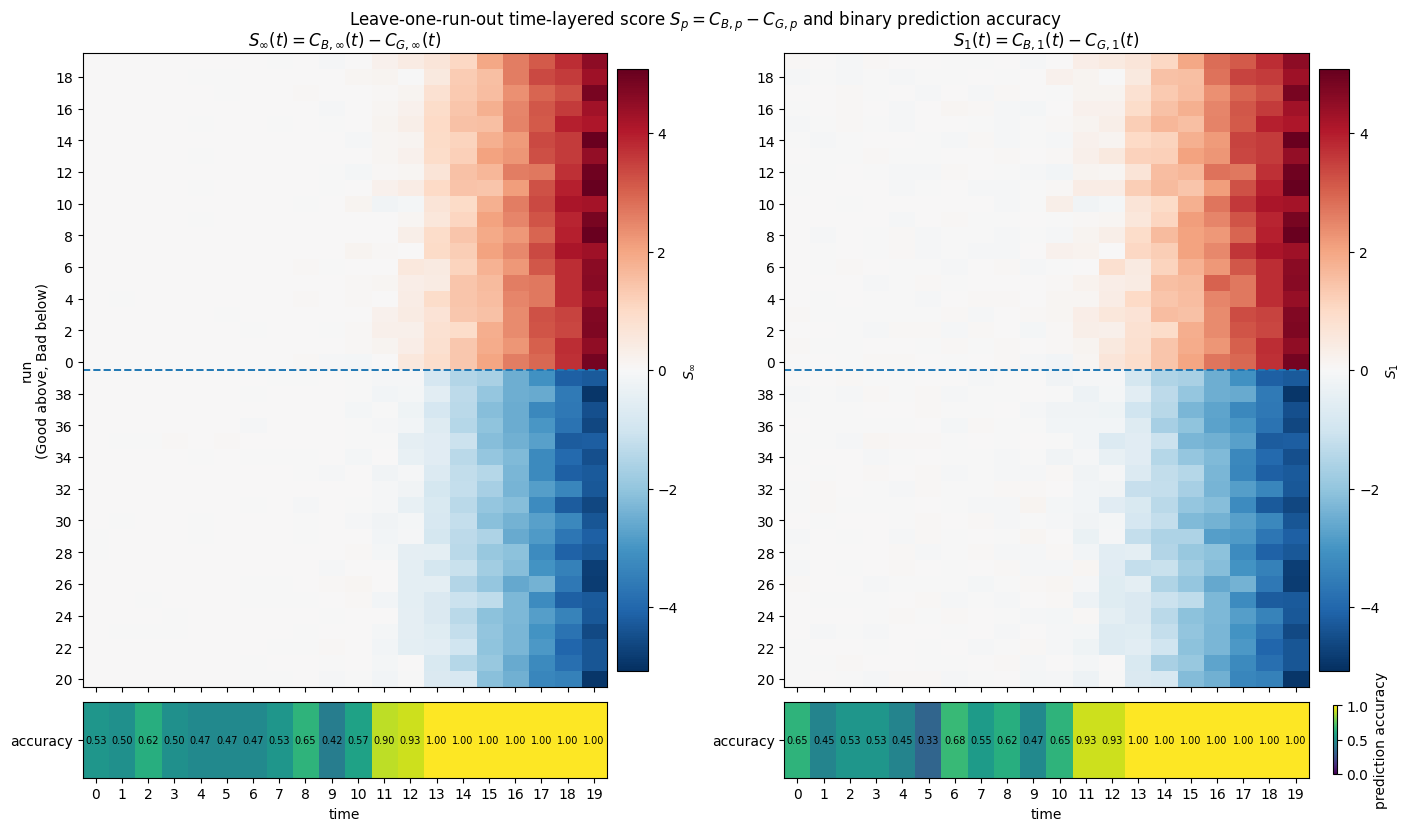

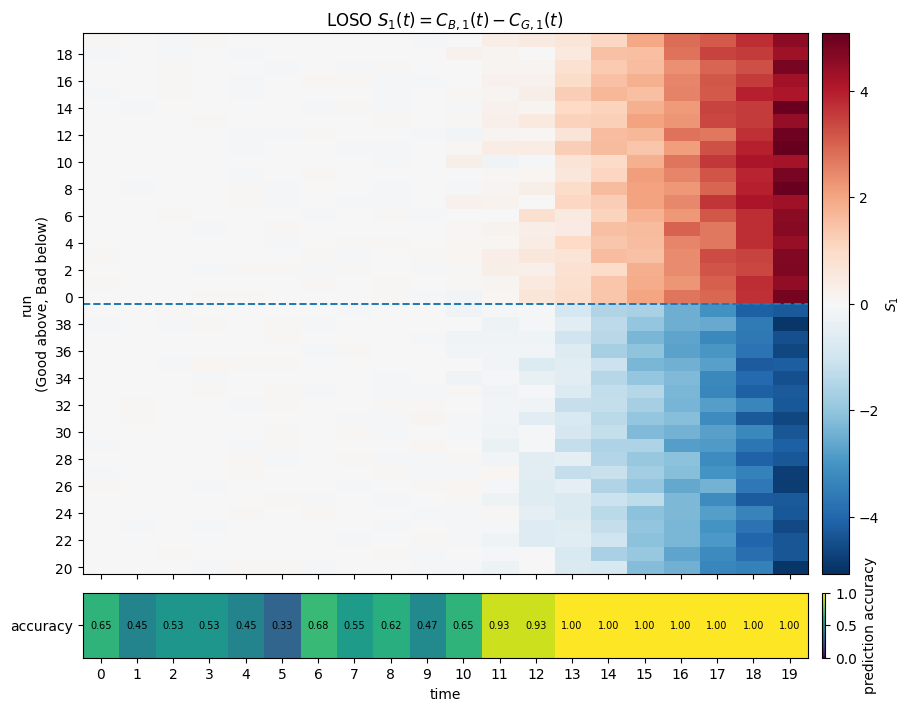

In [23]:
# ------------------------------------------------------------------
# Compute LOSO-CV S_p(t) for BOTH path costs and display:
#   1) run x time score heatmap
#   2) one-row time-resolved prediction-accuracy heatmap
#
# cv_eps (p=infinity) has already been computed above.
# ------------------------------------------------------------------

# p = 1 LOSO-CV
cv_eps_sum = leave_one_sequence_out_cv(
    adata,
    path_cost="sum",
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    verbose=True,
)


def loso_score_matrix(
    cv_frame,
    *,
    seq_key="seq_id",
    time_key="time_idx",
    score_key="margin_good",
):
    """
    Convert LOSO output into a run x time matrix of
    S_p = C_B,p - C_G,p.
    """
    seq_ids = np.sort(pd.unique(cv_frame[seq_key]))
    time_values = np.sort(pd.unique(cv_frame[time_key]))

    matrix = (
        cv_frame
        .pivot(index=seq_key, columns=time_key, values=score_key)
        .reindex(index=seq_ids, columns=time_values)
        .to_numpy(dtype=float)
    )

    if matrix.shape != (len(seq_ids), len(time_values)):
        raise ValueError(
            "Unexpected LOSO score-matrix shape: "
            f"{matrix.shape}; expected {(len(seq_ids), len(time_values))}."
        )
    if not np.isfinite(matrix).all():
        missing = np.argwhere(~np.isfinite(matrix))
        raise ValueError(
            "The LOSO score heatmap contains missing/non-finite values. "
            f"First locations: {missing[:10].tolist()}"
        )

    outcome = (
        cv_frame[[seq_key, "true_label"]]
        .drop_duplicates(subset=[seq_key])
        .set_index(seq_key)
        .reindex(seq_ids)["true_label"]
        .astype(str)
        .to_numpy()
    )

    return seq_ids, time_values, matrix, outcome


def binary_accuracy_by_time(score_matrix, outcomes):
    """
    Prediction rule:
        S_p > 0  -> Good
        S_p <= 0 -> Bad

    Returns one accuracy value for each time.
    """
    score_matrix = np.asarray(score_matrix, dtype=float)
    outcomes = np.asarray(outcomes, dtype=str)

    true_good = (outcomes == "good")[:, None]
    predicted_good = score_matrix > 0.0

    return np.mean(
        predicted_good == true_good,
        axis=0,
    )


def symmetric_limit(matrix, quantile=None):
    """Return a symmetric plotting limit around S_p=0."""
    values = np.abs(np.asarray(matrix, dtype=float))
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 1.0

    if quantile is None:
        vmax = float(np.max(values))
    else:
        vmax = float(np.quantile(values, quantile))

    return 1.0 if vmax == 0.0 else vmax


# ----------------------------------------------------------
# Build score matrices.
# ----------------------------------------------------------
seq_inf, time_inf, score_inf, outcome_inf = loso_score_matrix(cv_eps)
seq_one, time_one, score_one, outcome_one = loso_score_matrix(cv_eps_sum)

if not np.array_equal(seq_inf, seq_one):
    raise ValueError("p=infinity and p=1 LOSO runs are not aligned.")
if not np.array_equal(time_inf, time_one):
    raise ValueError("p=infinity and p=1 LOSO time grids are not aligned.")
if not np.array_equal(outcome_inf, outcome_one):
    raise ValueError("p=infinity and p=1 terminal outcomes are not aligned.")

loso_seq_ids = seq_inf
loso_time_values = time_inf
loso_outcomes = outcome_inf

# ----------------------------------------------------------
# Prediction accuracy at every time.
#
# Important: this is computed BEFORE display reordering.
# The ordering therefore has no effect on prediction accuracy.
# ----------------------------------------------------------
accuracy_inf = binary_accuracy_by_time(
    score_inf,
    loso_outcomes,
)
accuracy_one = binary_accuracy_by_time(
    score_one,
    loso_outcomes,
)

accuracy_table = pd.DataFrame(
    {
        "time_idx": loso_time_values,
        "accuracy_Linf": accuracy_inf,
        "accuracy_L1": accuracy_one,
    }
)

display(accuracy_table)


# ----------------------------------------------------------
# Display ordering: Bad at the bottom, Good at the top.
#
# With origin="lower", the first matrix row is drawn at the bottom.
# Therefore we put Bad rows first and Good rows last.
#
# This uses true outcomes ONLY to arrange rows visually.
# It does not affect fitting, held-out S_p, or accuracy.
# ----------------------------------------------------------
bad_positions = np.flatnonzero(loso_outcomes == "bad")
good_positions = np.flatnonzero(loso_outcomes == "good")
display_order = np.r_[bad_positions, good_positions]

display_seq_ids = loso_seq_ids[display_order]
display_outcomes = loso_outcomes[display_order]
display_score_inf = score_inf[display_order]
display_score_one = score_one[display_order]

n_bad_display = len(bad_positions)
n_good_display = len(good_positions)
outcome_boundary_y = n_bad_display - 0.5

# Independent numerical ranges because L_infinity and L_1 have
# different cost scales.
vmax_inf = symmetric_limit(score_inf)
vmax_one = symmetric_limit(score_one)

# Thin y ticks if many runs are present.
if len(display_seq_ids) <= 30:
    ytick_pos = np.arange(len(display_seq_ids))
else:
    step_y = max(1, len(display_seq_ids) // 20)
    ytick_pos = np.arange(0, len(display_seq_ids), step_y)

# Thin x ticks if necessary.
if len(loso_time_values) <= 25:
    xtick_values = loso_time_values
else:
    step_x = max(1, len(loso_time_values) // 12)
    xtick_values = loso_time_values[::step_x]


# ----------------------------------------------------------
# Two-column figure:
# upper row = S_p(run, time)
# lower row = accuracy(time)
# ----------------------------------------------------------
fig = plt.figure(
    figsize=(14, 8),
    constrained_layout=True,
)
gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[10.0, 1.2],
)

score_axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
]
accuracy_axes = [
    fig.add_subplot(gs[1, 0], sharex=score_axes[0]),
    fig.add_subplot(gs[1, 1], sharex=score_axes[1]),
]

score_configs = [
    (
        display_score_inf,
        vmax_inf,
        accuracy_inf,
        r"$S_\infty(t)=C_{B,\infty}(t)-C_{G,\infty}(t)$",
        r"$S_\infty$",
    ),
    (
        display_score_one,
        vmax_one,
        accuracy_one,
        r"$S_1(t)=C_{B,1}(t)-C_{G,1}(t)$",
        r"$S_1$",
    ),
]

accuracy_images = []

for col, (
    matrix,
    vmax,
    accuracy,
    title,
    cbar_label,
) in enumerate(score_configs):
    ax = score_axes[col]
    ax_acc = accuracy_axes[col]

    image = ax.imshow(
        matrix,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        extent=[
            loso_time_values[0] - 0.5,
            loso_time_values[-1] + 0.5,
            -0.5,
            len(display_seq_ids) - 0.5,
        ],
    )

    # Visual separation of the two true-outcome groups.
    if n_bad_display > 0 and n_good_display > 0:
        ax.axhline(
            outcome_boundary_y,
            linewidth=1.4,
            linestyle="--",
        )

    ax.set_title(title)
    ax.set_xticks(xtick_values)
    ax.tick_params(axis="x", labelbottom=False)

    cbar = fig.colorbar(
        image,
        ax=ax,
        shrink=0.95,
        pad=0.02,
    )
    cbar.set_label(cbar_label)

    # One-row accuracy heatmap.
    acc_image = ax_acc.imshow(
        accuracy[None, :],
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
        extent=[
            loso_time_values[0] - 0.5,
            loso_time_values[-1] + 0.5,
            -0.5,
            0.5,
        ],
    )
    accuracy_images.append(acc_image)

    ax_acc.set_yticks([0.0])
    ax_acc.set_yticklabels(["accuracy"])
    ax_acc.set_xticks(xtick_values)
    ax_acc.set_xlabel("time")

    # Numeric accuracy values are printed when the time grid is not too dense.
    if len(loso_time_values) <= 25:
        for time_value, value in zip(
            loso_time_values,
            accuracy,
        ):
            ax_acc.text(
                time_value,
                0.0,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=7,
            )

score_axes[0].set_ylabel(
    "run\n(Good above, Bad below)"
)
score_axes[0].set_yticks(ytick_pos)
score_axes[0].set_yticklabels(
    [str(display_seq_ids[i]) for i in ytick_pos]
)

# Because sharey is not used, apply the same y ticks to the right panel too.
score_axes[1].set_yticks(ytick_pos)
score_axes[1].set_yticklabels(
    [str(display_seq_ids[i]) for i in ytick_pos]
)

# Shared accuracy scale for the two one-row heatmaps.
accuracy_cbar = fig.colorbar(
    accuracy_images[0],
    ax=accuracy_axes,
    shrink=0.90,
    pad=0.02,
)
accuracy_cbar.set_label("prediction accuracy")

fig.suptitle(
    r"Leave-one-run-out time-layered score "
    r"$S_p=C_{B,p}-C_{G,p}$ and binary prediction accuracy",
    y=1.02,
)

plt.show()


# ----------------------------------------------------------
# Optional single-panel publication-style plot for one p.
# ----------------------------------------------------------
HEATMAP_PATH_COST = "sum"  # "max" or "sum"

if HEATMAP_PATH_COST == "max":
    selected_matrix = display_score_inf
    selected_vmax = vmax_inf
    selected_accuracy = accuracy_inf
    selected_title = (
        r"LOSO $S_\infty(t)=C_{B,\infty}(t)-C_{G,\infty}(t)$"
    )
    selected_label = r"$S_\infty$"
elif HEATMAP_PATH_COST == "sum":
    selected_matrix = display_score_one
    selected_vmax = vmax_one
    selected_accuracy = accuracy_one
    selected_title = r"LOSO $S_1(t)=C_{B,1}(t)-C_{G,1}(t)$"
    selected_label = r"$S_1$"
else:
    raise ValueError(
        "HEATMAP_PATH_COST must be 'max' or 'sum'."
    )

fig = plt.figure(
    figsize=(9, 7),
    constrained_layout=True,
)
gs = fig.add_gridspec(
    2,
    1,
    height_ratios=[10.0, 1.2],
)
ax = fig.add_subplot(gs[0, 0])
ax_acc = fig.add_subplot(gs[1, 0], sharex=ax)

image = ax.imshow(
    selected_matrix,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-selected_vmax,
    vmax=selected_vmax,
    extent=[
        loso_time_values[0] - 0.5,
        loso_time_values[-1] + 0.5,
        -0.5,
        len(display_seq_ids) - 0.5,
    ],
)

if n_bad_display > 0 and n_good_display > 0:
    ax.axhline(
        outcome_boundary_y,
        linewidth=1.4,
        linestyle="--",
    )

ax.set_ylabel(
    "run\n(Good above, Bad below)"
)
ax.set_title(selected_title)
ax.set_yticks(ytick_pos)
ax.set_yticklabels(
    [str(display_seq_ids[i]) for i in ytick_pos]
)
ax.set_xticks(xtick_values)
ax.tick_params(axis="x", labelbottom=False)

cbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.02,
)
cbar.set_label(selected_label)

acc_image = ax_acc.imshow(
    selected_accuracy[None, :],
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    vmin=0.0,
    vmax=1.0,
    extent=[
        loso_time_values[0] - 0.5,
        loso_time_values[-1] + 0.5,
        -0.5,
        0.5,
    ],
)
ax_acc.set_yticks([0.0])
ax_acc.set_yticklabels(["accuracy"])
ax_acc.set_xticks(xtick_values)
ax_acc.set_xlabel("time")

if len(loso_time_values) <= 25:
    for time_value, value in zip(
        loso_time_values,
        selected_accuracy,
    ):
        ax_acc.text(
            time_value,
            0.0,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

acc_cbar = fig.colorbar(
    acc_image,
    ax=ax_acc,
    pad=0.02,
)
acc_cbar.set_label("prediction accuracy")

plt.show()

### Prediction accuracy along the trajectory

The curves below summarize the same prediction rule used in the one-row
heatmaps: $S_p>0$ predicts Good and $S_p\le0$ predicts Bad.

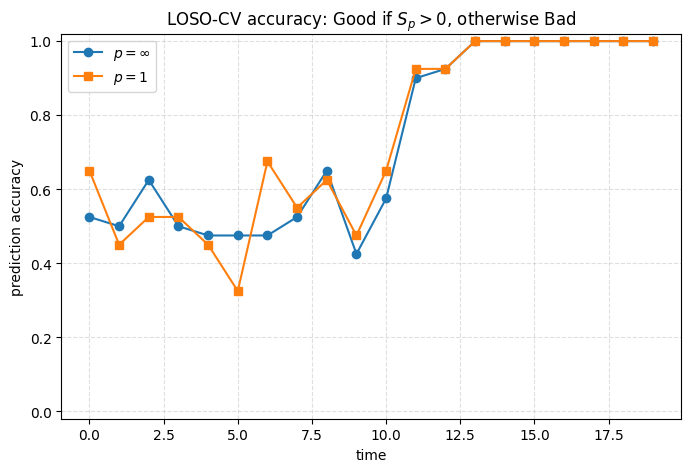

,time_idx,accuracy_Linf,accuracy_L1
0,0,0.525,0.650
1,1,0.500,0.450
2,2,0.625,0.525
3,3,0.500,0.525
4,4,0.475,0.450
5,5,0.475,0.325
6,6,0.475,0.675
7,7,0.525,0.550
8,8,0.650,0.625
9,9,0.425,0.475


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    loso_time_values,
    accuracy_inf,
    "o-",
    label=r"$p=\infty$",
)
ax.plot(
    loso_time_values,
    accuracy_one,
    "s-",
    label=r"$p=1$",
)

ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("time")
ax.set_ylabel("prediction accuracy")
ax.set_title(
    r"LOSO-CV accuracy: Good if $S_p>0$, otherwise Bad"
)
ax.grid(ls="--", alpha=0.4)
ax.legend()
plt.show()

accuracy_table

### $\varepsilon_G$ and $\varepsilon_B$ for representative held-out trajectories

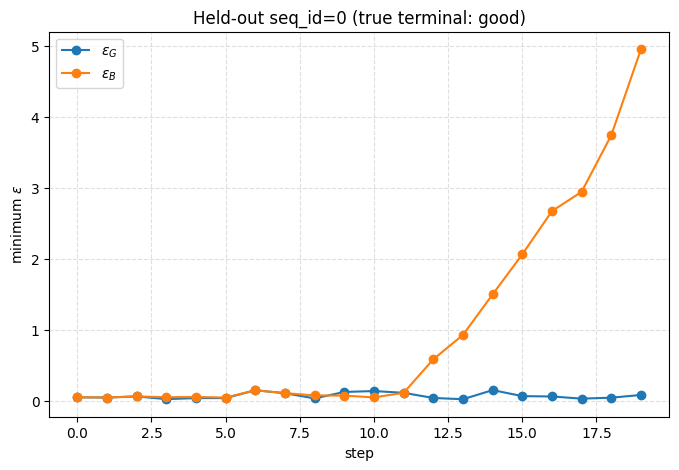

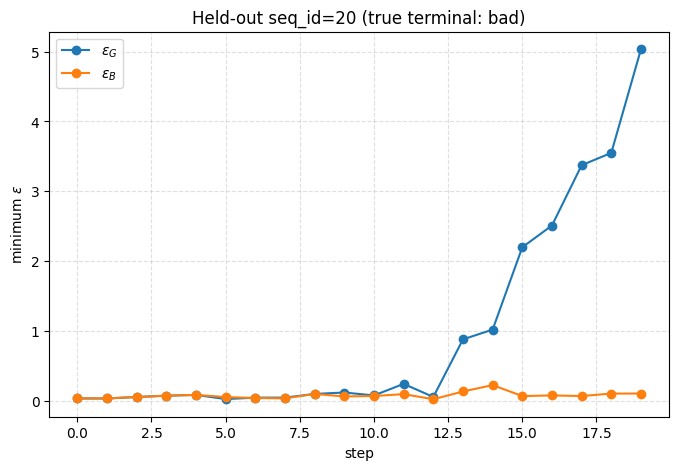

In [25]:
example_good_seq = terminal_cv.loc[
    terminal_cv["true_label"] == "good", "seq_id"
].iloc[0]
example_bad_seq = terminal_cv.loc[
    terminal_cv["true_label"] == "bad", "seq_id"
].iloc[0]

for sid in [example_good_seq, example_bad_seq]:
    df = cv_eps[cv_eps["seq_id"] == sid].sort_values("step")
    label = df["true_label"].iloc[0]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["step"], df["epsilon_good"], "o-", label=r"$\varepsilon_G$")
    ax.plot(df["step"], df["epsilon_bad"], "o-", label=r"$\varepsilon_B$")
    ax.set_xlabel("step")
    ax.set_ylabel(r"minimum $\varepsilon$")
    ax.set_title(f"Held-out seq_id={sid} (true terminal: {label})")
    ax.grid(ls="--", alpha=0.4)
    ax.legend()
    plt.show()

### Cross-validated Good/Bad margin in state space

We define

$$
M(x)=\varepsilon_B(x)-\varepsilon_G(x).
$$

Positive values favor Good and negative values favor Bad.

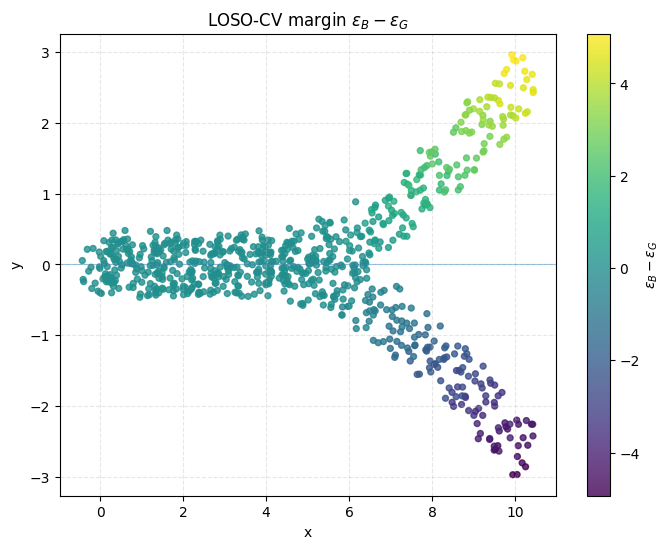

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    cv_eps["x"],
    cv_eps["y"],
    c=cv_eps["margin_good"],
    s=18,
    alpha=0.8,
)
ax.axhline(0.0, lw=0.8, alpha=0.4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"LOSO-CV margin $\varepsilon_B-\varepsilon_G$")
ax.grid(ls="--", alpha=0.3)
plt.colorbar(sc, ax=ax, label=r"$\varepsilon_B-\varepsilon_G$")
plt.show()

### Optional: LOSO-CV for $\varepsilon_\Sigma$

Set `RUN_EPS_SUM_CV = True` to repeat LOSO-CV using the time-layered additive ($p=1$) cost.

In [27]:
# p=1 LOSO-CV is already computed above for the S_p heatmap.
# Set this True only if you intentionally want to recompute it.
RUN_EPS_SUM_CV = False

if RUN_EPS_SUM_CV:
    cv_eps_sum = leave_one_sequence_out_cv(
        adata,
        path_cost="sum",
        seq_key="seq_id",
        time_key="time_idx",
        cluster_key="cluster",
        good_cluster_key="good",
        bad_cluster_key="bad",
        cost_matrix_key="cost_matrix",
        verbose=True,
    )

display(cv_eps_sum.head(10))

,path_cost,seq_id,step,time_idx,fraction,global_index,x,y,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct,entry_good_global_index,entry_bad_global_index
0,sum,0,0,0,0.000000,0,0.392749,0.070632,good,0.045768,0.058145,0.012377,good,True,160,560
1,sum,0,1,1,0.052632,1,0.710780,0.182812,good,0.043444,0.055336,0.011892,good,True,101,701
2,sum,0,2,2,0.105263,2,1.004222,-0.088817,good,0.097723,0.059007,-0.038716,bad,False,202,782
3,sum,0,3,3,0.157895,3,1.540252,-0.050838,good,0.021054,0.068682,0.047629,good,True,263,263
4,sum,0,4,4,0.210526,4,1.767755,-0.296941,good,0.035485,0.083873,0.048389,good,True,164,404
5,sum,0,5,5,0.263158,5,2.275895,0.325172,good,0.035352,0.043361,0.008009,good,True,385,505
6,sum,0,6,6,0.315789,6,3.547269,0.008826,good,0.147697,0.146134,-0.001564,bad,False,66,546
7,sum,0,7,7,0.368421,7,4.108171,-0.017590,good,0.104761,0.137553,0.032792,good,True,27,247
8,sum,0,8,8,0.421053,8,4.065269,-0.273527,good,0.030749,0.073283,0.042534,good,True,108,588
9,sum,0,9,9,0.473684,9,4.453780,-0.275514,good,0.121955,0.070527,-0.051428,bad,False,209,509


## Pointwise prediction reliability for an arbitrary state $x$

A single state does not have an ordinary sample **accuracy**.  Instead, we
estimate the probability that the fixed landscape-sign prediction is correct.
For each time layer and each perturbation norm, strict LOSO scores are used to
fit the monotone calibration map

$$
q_{p,t}(s) \approx P(Y=G\mid S_p=s,t),
\qquad
S_p=C_{B,p}-C_{G,p}.
$$

The landscape prediction itself is kept fixed:

$$
\hat Y_p(x)=G \quad\text{if } S_p(x)>0,
\qquad
\hat Y_p(x)=B \quad\text{if } S_p(x)\le 0.
$$

For a new state $x$, the **pointwise prediction reliability** is

$$
R_p(x)=
\begin{cases}
q_{p,t}(S_p(x)), & \hat Y_p(x)=G,\\
1-q_{p,t}(S_p(x)), & \hat Y_p(x)=B.
\end{cases}
$$

Here we use time-specific isotonic regression.  This is intentionally a simple
calibration example: with only 40 trajectories, the fitted curve is a
staircase and should not be interpreted as a precise probability estimate.
For publication-level uncertainty quantification, nested/cross-fitted
calibration or a pooled time-dependent probabilistic model should be used.


In [28]:
def fit_timewise_isotonic_calibrators(
    cv_frame,
    *,
    score_column="margin_good",
    time_column="time_idx",
    label_column="true_label",
    good_label="good",
):
    """Fit q_t(s) ~= P(Good | S=s, time=t) from OOS/LOSO scores only."""
    calibrators = {}
    summary_rows = []

    for time_value, group in cv_frame.groupby(time_column, sort=True):
        scores = group[score_column].to_numpy(dtype=float)
        y_good = (
            group[label_column].astype(str).to_numpy() == good_label
        ).astype(float)

        finite = np.isfinite(scores)
        scores = scores[finite]
        y_good = y_good[finite]
        if scores.size < 2:
            raise ValueError(
                f"Not enough finite calibration scores at time={time_value}."
            )

        model = IsotonicRegression(
            y_min=0.0,
            y_max=1.0,
            increasing=True,
            out_of_bounds="clip",
        )
        model.fit(scores, y_good)

        calibrators[int(time_value)] = {
            "model": model,
            "score_min": float(np.min(scores)),
            "score_max": float(np.max(scores)),
            "n_samples": int(scores.size),
            "good_fraction": float(np.mean(y_good)),
        }
        summary_rows.append(
            {
                "time_idx": int(time_value),
                "n_samples": int(scores.size),
                "score_min": float(np.min(scores)),
                "score_max": float(np.max(scores)),
                "good_fraction": float(np.mean(y_good)),
            }
        )

    return calibrators, pd.DataFrame(summary_rows)


calibrators_inf, calibration_summary_inf = (
    fit_timewise_isotonic_calibrators(cv_eps)
)
calibrators_one, calibration_summary_one = (
    fit_timewise_isotonic_calibrators(cv_eps_sum)
)

print("L-infinity calibration summary")
display(calibration_summary_inf.head())
print("L1 calibration summary")
display(calibration_summary_one.head())


L-infinity calibration summary


,time_idx,n_samples,score_min,score_max,good_fraction
0,0,40,-0.021117,0.008492,0.5
1,1,40,-0.012182,0.025267,0.5
2,2,40,-0.022642,0.024994,0.5
3,3,40,-0.034249,0.053302,0.5
4,4,40,-0.027613,0.027613,0.5


L1 calibration summary


,time_idx,n_samples,score_min,score_max,good_fraction
0,0,40,-0.056308,0.047690,0.5
1,1,40,-0.055291,0.047629,0.5
2,2,40,-0.061573,0.062261,0.5
3,3,40,-0.065172,0.090138,0.5
4,4,40,-0.072892,0.062261,0.5


### Reusable evaluator: $C_G$, $C_B$, $S$, optimal paths, and reliability

The following function can be called for any external state `x`, provided that
`costs` contains the cost from that state to the ensemble observations.  In
time-layered mode, only the costs to the requested time layer need to be finite.


In [29]:
def evaluate_query_with_reliability(
    adata_obj,
    x,
    costs,
    *,
    output_key,
    time_value,
    calibrators,
):
    """Evaluate an external x and attach calibrated pointwise reliability."""
    result = minimum_epsilon_and_paths_to_good_bad(
        adata_obj,
        x,
        costs,
        output_key=output_key,
        time_value=time_value,
    )

    score = float(result.epsilon_bad - result.epsilon_good)
    prediction = "good" if score > 0.0 else "bad"

    time_key = int(time_value)
    if time_key not in calibrators:
        raise KeyError(
            f"No calibration model is available for time={time_value}."
        )
    calibration = calibrators[time_key]
    probability_good = float(
        calibration["model"].predict([score])[0]
    )
    probability_bad = 1.0 - probability_good
    reliability = (
        probability_good
        if prediction == "good"
        else probability_bad
    )

    score_min = calibration["score_min"]
    score_max = calibration["score_max"]
    within_support = bool(score_min <= score <= score_max)

    return {
        "path_result": result,
        "C_G": float(result.epsilon_good),
        "C_B": float(result.epsilon_bad),
        "S": score,
        "prediction": prediction,
        "P_good": probability_good,
        "P_bad": probability_bad,
        "reliability": float(reliability),
        "within_calibration_support": within_support,
        "calibration_score_min": score_min,
        "calibration_score_max": score_max,
    }


### Evaluate the same external query $x$

The previously selected `x_query` is now assigned not only $C_G$, $C_B$, and
$S$, but also $P(G\mid S,t)$ and the estimated probability that the fixed sign
prediction is correct.


In [30]:
query_reliability_inf = evaluate_query_with_reliability(
    adata,
    x_query,
    query_costs,
    output_key="eps_attracting_basin_sp",
    time_value=QUERY_TIME_IDX,
    calibrators=calibrators_inf,
)
query_reliability_one = evaluate_query_with_reliability(
    adata,
    x_query,
    query_costs,
    output_key="eps_sum_attracting_basin_sp",
    time_value=QUERY_TIME_IDX,
    calibrators=calibrators_one,
)

query_reliability_table = pd.DataFrame(
    [
        {
            "p": "infinity",
            **{
                key: query_reliability_inf[key]
                for key in (
                    "C_G",
                    "C_B",
                    "S",
                    "prediction",
                    "P_good",
                    "P_bad",
                    "reliability",
                    "within_calibration_support",
                    "calibration_score_min",
                    "calibration_score_max",
                )
            },
        },
        {
            "p": "1",
            **{
                key: query_reliability_one[key]
                for key in (
                    "C_G",
                    "C_B",
                    "S",
                    "prediction",
                    "P_good",
                    "P_bad",
                    "reliability",
                    "within_calibration_support",
                    "calibration_score_min",
                    "calibration_score_max",
                )
            },
        },
    ]
)

display(query_reliability_table)

for p_name, item in [
    ("L-infinity", query_reliability_inf),
    ("L1", query_reliability_one),
]:
    support_note = (
        "inside"
        if item["within_calibration_support"]
        else "OUTSIDE"
    )
    print(
        f"{p_name}: prediction={item['prediction']}, "
        f"estimated reliability={item['reliability']:.3f}, "
        f"P(G)={item['P_good']:.3f}, "
        f"score support={support_note} "
        f"[{item['calibration_score_min']:.3f}, "
        f"{item['calibration_score_max']:.3f}]"
    )


,p,C_G,C_B,S,prediction,P_good,P_bad,reliability,within_calibration_support,calibration_score_min,calibration_score_max
0,infinity,0.089276,0.115482,0.026205,good,0.719194,0.280806,0.719194,True,-0.050080,0.051303
1,1,0.089276,0.162571,0.073294,good,1.000000,0.000000,1.000000,False,-0.068732,0.062261


L-infinity: prediction=good, estimated reliability=0.719, P(G)=0.719, score support=inside [-0.050, 0.051]
L1: prediction=good, estimated reliability=1.000, P(G)=1.000, score support=OUTSIDE [-0.069, 0.062]


### Calibration curves at the query time

Dots are the strict LOSO observations at the same time layer.  The solid curve
is the isotonic estimate of $P(G\mid S_p,t)$, and the star is the external
query state.  The vertical dashed line at $S=0$ is the fixed landscape decision
boundary; it is **not** refitted during calibration.


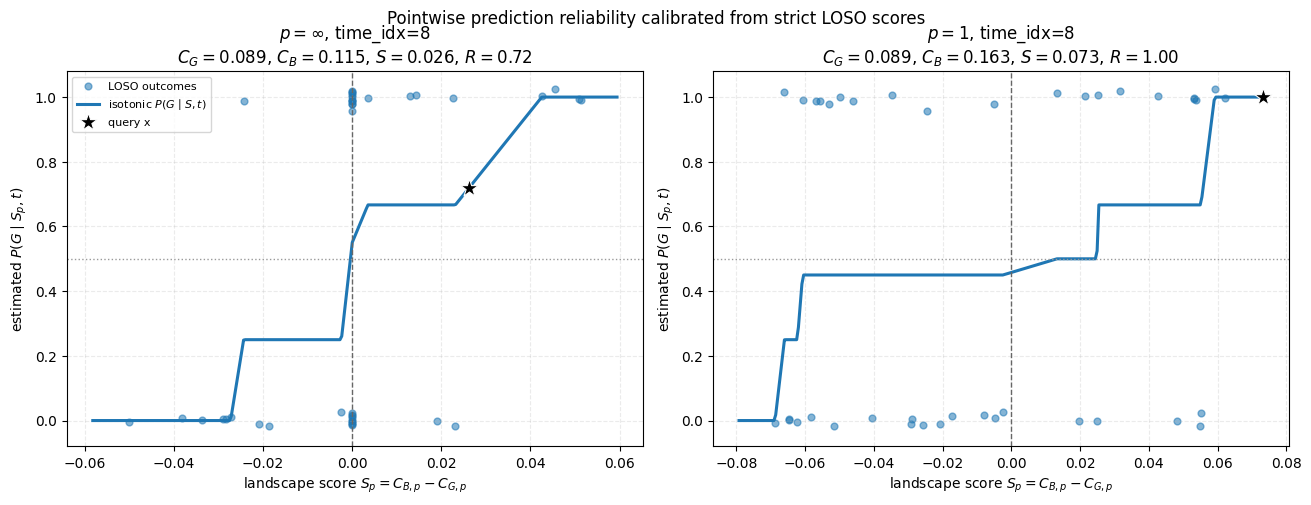

In [31]:
def plot_query_calibration(
    ax,
    *,
    cv_frame,
    calibrators,
    query_info,
    time_value,
    title,
):
    group = cv_frame.loc[
        cv_frame["time_idx"].to_numpy(dtype=int) == int(time_value)
    ].copy()
    scores = group["margin_good"].to_numpy(dtype=float)
    y_good = (
        group["true_label"].astype(str).to_numpy() == "good"
    ).astype(float)

    calibration = calibrators[int(time_value)]
    s_min = calibration["score_min"]
    s_max = calibration["score_max"]
    if np.isclose(s_min, s_max):
        pad = max(1e-6, 0.1 * max(1.0, abs(s_min)))
        grid = np.linspace(s_min - pad, s_max + pad, 200)
    else:
        pad = 0.08 * (s_max - s_min)
        grid = np.linspace(s_min - pad, s_max + pad, 300)

    p_good_grid = calibration["model"].predict(grid)

    rng_local = np.random.default_rng(0)
    jitter = rng_local.normal(0.0, 0.018, size=len(y_good))
    ax.scatter(
        scores,
        np.clip(y_good + jitter, -0.06, 1.06),
        s=24,
        alpha=0.55,
        label="LOSO outcomes",
    )
    ax.plot(
        grid,
        p_good_grid,
        linewidth=2.2,
        label=r"isotonic $P(G\mid S,t)$",
    )
    ax.axvline(0.0, color="0.4", ls="--", lw=1.0)
    ax.axhline(0.5, color="0.6", ls=":", lw=1.0)
    ax.scatter(
        [query_info["S"]],
        [query_info["P_good"]],
        marker="*",
        s=180,
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=10,
        label="query x",
    )

    ax.set_ylim(-0.08, 1.08)
    ax.set_xlabel(r"landscape score $S_p=C_{B,p}-C_{G,p}$")
    ax.set_ylabel(r"estimated $P(G\mid S_p,t)$")
    ax.set_title(
        title
        + "\n"
        + rf"$C_G={query_info['C_G']:.3f}$, "
          rf"$C_B={query_info['C_B']:.3f}$, "
          rf"$S={query_info['S']:.3f}$, "
          rf"$R={query_info['reliability']:.2f}$"
    )
    ax.grid(ls="--", alpha=0.25)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
    constrained_layout=True,
)
plot_query_calibration(
    axes[0],
    cv_frame=cv_eps,
    calibrators=calibrators_inf,
    query_info=query_reliability_inf,
    time_value=QUERY_TIME_IDX,
    title=rf"$p=\infty$, time_idx={QUERY_TIME_IDX}",
)
plot_query_calibration(
    axes[1],
    cv_frame=cv_eps_sum,
    calibrators=calibrators_one,
    query_info=query_reliability_one,
    time_value=QUERY_TIME_IDX,
    title=rf"$p=1$, time_idx={QUERY_TIME_IDX}",
)
axes[0].legend(frameon=True, fontsize=8, loc="best")
fig.suptitle(
    "Pointwise prediction reliability calibrated from strict LOSO scores",
    y=1.02,
)
plt.show()


### Global accuracy versus pointwise reliability

`accuracy(t)` below is a property of the collection of held-out trajectories,
whereas `reliability(x)` is a property assigned to the single external query
through the calibrated LOSO score distribution.  They should not be called the
same quantity.


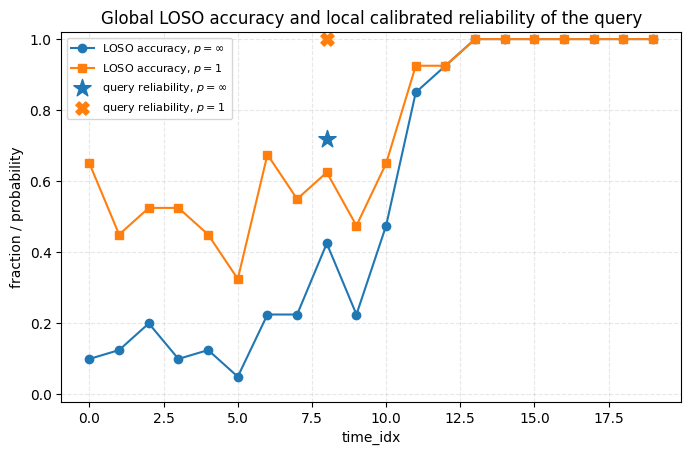

In [32]:
def accuracy_by_time(frame):
    return (
        frame.groupby("time_idx", as_index=False)
        .agg(
            accuracy=("correct", "mean"),
            n=("correct", "size"),
        )
    )

accuracy_inf_time = accuracy_by_time(cv_eps)
accuracy_one_time = accuracy_by_time(cv_eps_sum)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(
    accuracy_inf_time["time_idx"],
    accuracy_inf_time["accuracy"],
    "o-",
    label=r"LOSO accuracy, $p=\infty$",
)
ax.plot(
    accuracy_one_time["time_idx"],
    accuracy_one_time["accuracy"],
    "s-",
    label=r"LOSO accuracy, $p=1$",
)

ax.scatter(
    [QUERY_TIME_IDX],
    [query_reliability_inf["reliability"]],
    marker="*",
    s=170,
    label=r"query reliability, $p=\infty$",
)
ax.scatter(
    [QUERY_TIME_IDX],
    [query_reliability_one["reliability"]],
    marker="X",
    s=90,
    label=r"query reliability, $p=1$",
)

ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("time_idx")
ax.set_ylabel("fraction / probability")
ax.set_title(
    "Global LOSO accuracy and local calibrated reliability of the query"
)
ax.grid(ls="--", alpha=0.3)
ax.legend(frameon=True, fontsize=8)
plt.show()


### Interpretation for control-oriented use

For an arbitrary state $x$, the notebook now returns two different kinds of
information:

1. **Predictability:** the fixed sign prediction and its calibrated reliability
   $R_p(x)$.
2. **Accessibility/control cost:** $C_{G,p}(x)$, $C_{B,p}(x)$, and the optimal
   paths realizing those costs.

For example, if the state is predicted Bad with high $R_p(x)$ but
$C_{G,p}(x)$ remains below an admissible perturbation budget, the state is both
sufficiently diagnosed and still redirectable toward Good under the assumed
controlled-path model.  This is the intended bridge between prediction and
candidate intervention-path analysis.


## Visualization inventory retained

The original visualizations from the uploaded LOSO/accuracy notebook are kept, and the arbitrary-state optimal-path and pointwise-reliability visualizations are added on top of them.
